In [1]:
# preamble
using Revise
using Profile
using Pkg; Pkg.activate(".")

using Dates
using Statistics, LinearAlgebra, SparseArrays
using TotalLeastSquares
using Rotations
using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf
using Distributions

include("./read_lidar.jl")
using .read_lidar
using .read_lidar.stare
using .read_vecnav: read_vecnav_dict
import .chunks
read_stare_time  = Main.chunks.read_stare_time
read_stare_chunk = Main.chunks.read_stare_chunk
fit_offset = Main.chunks.fit_offset

include("./DopplerTurbulence.jl")
using .DopplerTurbulence

include("./timing_lidar.jl")
using .timing_lidar
include("./readers.jl")
using .NoaaDas: cat_dicts
# using MAT

using PythonPlot

  Activating project at `~/Projects/lidar/ASTRAL2024`
  Activating project at `~/Projects/lidar/ASTRAL2024`


In [2]:
# utility functions extend Py[thon]Plot

# Methods for PyPlot or PythonPlot handle missing by wrapping in np.ma masked arrays.
if @isdefined(PythonPlot)
	import PythonPlot: PythonCall
	using PythonCall: Py

	# Extend the PythonCall converter to handle Missing arrays
	# Catch arrays with Missing elements and wrap them for PythonCall
	function PythonCall.Py(a::AbstractArray{Union{T, Missing}, N}) where {T<:Number, N}
		# Import numpy.ma (masked arrays)
		np = PythonCall.pyimport("numpy")
		
		# Create the data and mask (these are eager but efficient)
		data = coalesce.(a, zero(T))
		mask = ismissing.(a)
		
		# Return the NumPy masked array
		return np.ma.masked_array(data, mask=mask, dtype="float64")
	end

	function PythonCall.Py(a::AbstractArray{Union{T, Missing}, N}) where {T<:TimeType, N}
		# Import numpy.ma (masked arrays)
		np = PythonCall.pyimport("numpy")
		mdates = PythonCall.pyimport("matplotlib.dates")

		# Create the data and mask (these are eager but efficient)
		data = coalesce.(a, DateTime(1970,1,1))
		mask = ismissing.(a)
		
		# Return the NumPy masked array
		return np.ma.masked_array(data, mask=mask)
	end

    "close plots with close(\"all\")"
    close(s::String) = PythonCall.pyimport("matplotlib.pyplot").close(s)

elseif @isdefined(PyPlot)
	using PyCall
	using PyCall: PyObject
	# allow for plotting with missing values
	function PyCall.PyObject(a::Array{Union{T,Missing},N}) where {T,N}
		numpy_ma = PyCall.pyimport("numpy").ma
		pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
	end
end

# "convert arrays with missings to masked python float64 arrays"
# msk(y) = ma.masked_invalid(np.array(replace(y, missing => NaN), dtype="float64"))


"plotf(f, x, args...)  function plot wrapper"
plotf(f, x, args...) = plot(x, f.(x), args...)

plotf

In [3]:
# function library with utility functions,  functions for subsetting, for displacements, and for structure functions

# utility functions
pd = permutedims
m2n(x) = ismissing(x) ? NaN : x
good(x) = !ismissing(x) & isfinite(x)

"""
    binavg(y, x, b; f=identity, w=y->1)
Bin average y(x) in bins b of coordinate x.
Skip missing by passing the optional function arguments
f(y) = ismissing(y) ? 0 : y;   w(y) = !ismissing(y)
"""
function binavg(y, x, b; f=identity, w=y->1)
    a = zeros(length(b))
    c = zeros(length(b))
    for (i,x) in enumerate(x)
        bi = searchsortedlast(b, x)
        bi = clamp(bi, 1, length(b))
        a[bi] += f(y[i])
        c[bi] += w(y[i])
    end
    return a./c
end

"""
    binavgvar(y, x, b; f=identity, w=y->1)
Bin average y(x) in bins b of coordinate x.
Returns bin mean and variance.
Skip missing by passing the optional function arguments
f(y) = ismissing(y) ? 0 : y;   w(y) = !ismissing(y)
"""
function binavgvar(y, x, b; f=identity, w=y->1)
    a     = zeros(length(b))
    a2    = zeros(length(b))
    count = zeros(length(b))
    for (i,x) in enumerate(x)
        bi = searchsortedlast(b, x)
        bi = clamp(bi, 1, length(b))
        a[bi]      += f(y[i])
        a2[bi]     += a[bi]^2
        count[bi]  += w(y[i])
    end
    avg = a ./count
    var = a2./count .- avg.^2
    return avg, var
end

# functions for masking and averaging data
noisethr = 1.05 # parameter for masking lidar data
# increase from 1.03 to 1.05 May 8, 2026

"NaN -> missing"
n2m(x) = isfinite.(x) ? x : missing

"result is x; set to missing iff i<thr"
masklowi(x, i, thr=noisethr) = i<thr ? missing : x

"mean along dimension dims, skipping missing"
missmean(X; dims=1) = mapslices(x -> mean(skipmissing(x)), X, dims=dims)

f(x) = x>noisethr # use intensity for x

# # mean Doppler velocity # OLD and tested
# function get_mdv(f, dopplervel)
#     X = missingnoise.(f, dopplervel)
#     mapslices(x->mean(skipmissing(x)), X; dims=2)[:]
# end

# Suggest only computing mdv (for motion removal) where
# there are nonnoise DVs for the whole chunk, so not to alias sampling differences.
# Then, only take the mean of the middle 5th quantile, to smoothly approximate the mode

"""
Motion from Doppler velocity, by inferring displacement of the median velocity 
by the platform motion at each time.
"""
function get_mdv(f, intensity, dopplervel)
    # levels with Doppler data at all times in the chunk
    goodlevels = findall(all(f, intensity; dims=1)[:]) # bool --> indices
    # median over whole chunk, continuously available levels
    chunkmedian = median(dopplervel[:,goodlevels]) # over both dims
    # median over vertical dim at each time
    timeslicemedian = median(dopplervel[:,goodlevels], dims=2)
    mdv = timeslicemedian .- chunkmedian
end
# UNTESTED!!
# This modification circumvents issues with sampling and better separates the motion estimate
# from the air velocities, assuming the median of the overall velocity distribution is 
# unchanged, and the Doppler velocity is merely shifted at each time by the platform motion,
# but with zero average shift since mean(motion) = median(motion) = 0.

remove_mdv(f, intensity, dopplervel) = dopplervel .- get_mdv(f, intensity, dopplervel)
remove_mdv!(f, intensity, dopplervel) = (dopplervel .-= get_mdv(f, intensity, dopplervel))

"anomaly"
anom(x; dims=1) = x.-mean(x; dims=dims)

# highpass filter
"""
hp(x, fcutoff=1/80)    highpass filter x,
by default filtfilt 4th-order Butterworth, fs=1
"""
function hp(x, fcutoff=1/80;
    order=4,
    designmethod=Butterworth(order), 
    fs=1,
    responsetype = Highpass(fcutoff; fs=fs) )
    
    filtfilt(digitalfilter(responsetype, designmethod), x)
end


# make simple linear temporal interpolation
# maybe fast
# most time is spent searching for indices
# indices are monotonic

"""
Return all the indices i such that each xl[i] is the first >= each xs.
Assumes xs, xl are ordered and loops through xs only once.
Quarry for needles xs in haystack xl.
"""
function findindices(xs, xl)
    # needles xs define quarries in haystack xl
    xs = filter(x -> x<=last(xl), xs) # prefilter to avoid running off the end of xl
    ind = zeros(Int64, size(xs))
    i = 1
    for (j,x) in enumerate(xs)
        while xl[i] < x
            i += 1
        end
        ind[j] = i
    end
    return ind
end

"average xl within windows to right of points of the index ind of xl"
function indavg(xl, ind; full=20)
    xm = zeros(Float64, size(ind))
    for (i,idx) in enumerate(ind)
        ii = max(1,idx) : min(length(xl),idx+full)
        # xm[i] = sum(Float64.(xl[ii])) / (full+1)
        xm[i] = mean(Float64.(xl[ii]))
    end
    return xm
end

# test data (precompiles)
let xl = 1:60_000_000, xs = 20:20:60_000_000
    ind = findindices(xs, xl)
    indavg(xl, ind)
end

# Adjust true vertical velocity for relative wind * sin(tilt)
# and the platform velocity
trigs(pitch, roll) = ( cos(pitch), sin(pitch), cos(roll), sin(roll) )
# cospitch, sinpitch, cosroll, sinroll = trigs(pitch, roll)

function wtrue_trigs(w, Ur, Vr, pitch, roll)
    # approximate, better to use rotations
    cospitch, sinpitch, cosroll, sinroll = trigs(pitch, roll)
    wtrue = ( w + Ur*sinpitch - Vr*cospitch*sinroll ) / (cospitch*cosroll)
end

"""
wtrue(dopplervel, Ur, Vr, heaveveldown, roll, pitch)
Return true radial velocity component in lidar beam frame (+away).
Rotate vertical VelNED and mean ship-relative wind (Ur, Vr)
from inertial level ship coorindates 
to lidar beam coordinates using roll and pitch.
"""
function wtrue( dopplervel, Ur, Vr, heaveveldown, roll, pitch )
    # external ship frame
    vvn_ship = [0, 0, heaveveldown] # VectorNav vertical velocity vector (NED coordinate)
    wnd_ship = [Ur, Vr, 0]          # mean horizontal relative wind, w=0 (NED coordinate)
    wnd_vn_ship = wnd_ship - vvn_ship

    # rotate from ship NED frame to lidar NED frame
    R = RotX(roll*π/180) * RotY(pitch*π/180)

    # mean vertical-radial-lidar relative velocity in the lidar platform body frame (NED)
    # includes heave-induced velocity
    wnd_lidar =  R * wnd_vn_ship # lidar NED frame (down-positive) vector

    # signs: lidar upward heave vel > 0 ==> lidar VelNED2 < 0, induced radial velocity < 0 (towards)

    # scalar true radial velocity (+up), adjusting for heave velocity
    # and mean wind component in beam direction.
    # wturb and dopplervel is away-positive. true radialvel is dopplervel + platform vel
    # wtrue = wrel + wplatform
    # trueradialvel is +up
    trueradialvel = dopplervel + -wnd_lidar[3] # negate downward wnd_lidar: NED +down, dopplervel +up
end

function wtrue( dopplervel, surgevel, swayvel, heaveveldown, Ur, Vr, roll, pitch )
    # external ship frame
    vvn_ship = [surgevel, swayvel, heaveveldown] # VectorNav vertical velocity vector (NED coordinate)
    #vvn_ship = [VelNED0, VelNED1, VelNED2]
    wnd_ship = [Ur, Vr, 0]          # mean horizontal relative wind, w=0 (NED coordinate)
    wnd_vn_ship = wnd_ship - vvn_ship

    # rotate from ship NED frame to lidar NED frame
    R = RotX(roll*π/180) * RotY(pitch*π/180)

    # mean vertical-radial-lidar relative velocity in the lidar platform body frame (NED)
    # includes heave-induced velocity
    wnd_lidar =  R * wnd_vn_ship # lidar NED frame (down-positive) vector

    # signs: lidar upward heave vel > 0 ==> lidar VelNED2 < 0, induced radial velocity < 0 (towards)

    # scalar true radial velocity (+up), adjusting for heave velocity
    # and mean wind component in beam direction.
    # wturb and dopplervel is away-positive. true radialvel is dopplervel + platform vel
    # wtrue = wrel + wplatform
    # trueradialvel is +up
    trueradialvel = dopplervel + -wnd_lidar[3] # negate downward wnd_lidar: NED +down, dopplervel +up
end

# functions for indexing sample pairs for structure functions

# generate unique pairs of indices
"index unique pairs in a vector of length n"
function uniquepairs(n) 
    [ [l1, l2] for l1 in 1:n for l2 in (l1+1):n ]
end
"index pairs of points in adjacent levels"
allcross(n) = [ [l1, l2] for l1 in 1:n for l2 in 1:n ]

# beam geometry
"lidar beam range"
rng(iz, rangegate=24.0) = rangegate * (iz-1 + 0.5)

"""
compile indices of lidar volumes to be compared with
structure functions
"""
function lidarindices(nt, nz, z1=1; nlevelstats=1)
    if nlevelstats == 3
        # The complete set that doesn't repeat pairs is 
        # 1 the complete set of nt*(n-1)/2 pairs for the top level (3)
        # 2 the 2*nt*nt sets of pairs between every point in top (3) level and the next 2 levels
        # Iteratively slide this box upward by 1 level for each level.
    
        # index pairs in middle level 2-2
        up = uniquepairs(nt)
        it1 = map(i->i[1], up) # time indices for pairs of point1, point2
        it2 = map(i->i[2], up)
        ci1_r22 = CartesianIndex.(tuple.(it1,z1)) # 1st point in pair lev
        ci2_r22 = CartesianIndex.(tuple.(it2,z1)) # 2nd 
    
        # index pairs of points from level 2-1, and 2-3
        ac = allcross(nt)
        it1 = map(i->i[1], ac)
        it2 = map(i->i[2], ac)
        ci1_r21 = ci1_r23 = CartesianIndex.(tuple.(it1,2))
        ci2_r21 = CartesianIndex.(tuple.(it2,z1-1))
        ci2_r23 = CartesianIndex.(tuple.(it2,z1+1))
    
        # omnibus set of cartesian index pairs for a level, including points in lev above and below
        ci1 = [ci1_r23; ci1_r22; ci1_r21] # first of pairs
        ci2 = [ci2_r23; ci2_r22; ci2_r21]
        li1 = LinearIndices(ci1)
        li2 = LinearIndices(ci2)
        
    elseif nlevelstats == 1
        # just use structure function velocity pairs from one level of lidar range
        up = uniquepairs(nt)
        it1 = map(i->i[1], up) # time indices for pairs of point1, point2
        it2 = map(i->i[2], up)
        ci1_r11 = CartesianIndex.(tuple.(it1,z1)) # 1st point in pair lev
        ci2_r11 = CartesianIndex.(tuple.(it2,z1)) # 2nd point in same lev
    
        # set of cartesian index pairs for a level, including points in lev above and below
        ci1 = ci1_r11 # first of pairs
        ci2 = ci2_r11
        li1 = LinearIndices(ci1)
        li2 = LinearIndices(ci2)
    end
    
    it1 = map(idx->idx[1], ci1) #  t index of first point(s)
    iz1 = map(idx->idx[2], ci1) #  z index of first
    it2 = map(idx->idx[1], ci2) #  t       of second points(s)
    iz2 = map(idx->idx[2], ci2) #  z          second
    
    return ci1,ci2, li1,li2, it1,iz1,it2,iz2
end

# try example
ci1,ci2, li1,li2, it1,iz1,it2,iz2 = lidarindices(1000, 80)

# functions for displacments and structure functions 

rangegate = 24.0 # for ASTRAL 2024 Halo Photonics StreamLineXR

"""
zm, dr2, dz2, D2 = displacements( ci1,ci2, Udt,Vdt, pitch,roll, w; rangegate=rangegate)
Displacements of sample pairs for one (vertical) subvolume.
    pitch and roll in radians.
"""
function displacements( ci1,ci2, Udt,Vdt, pitch,roll, w; rangegate=rangegate , timestep=timestep)
    # get the individual indices
    it1 = map(idx->idx[1], ci1) #  t index of first point(s)
    iz1 = map(idx->idx[2], ci1) #  z index of first
    it2 = map(idx->idx[1], ci2) #  t       of second points(s)
    iz2 = map(idx->idx[2], ci2) #  z          second

    rng(iz) = rangegate * (iz-1 + 0.5) # center of gates

    # horiz translation of the sample volumes by mean wind
    Udtbar = @. (Udt[iz2] + Udt[iz1]) / 2
    Vdtbar = @. (Vdt[iz2] + Vdt[iz1]) / 2
    X = @. Udtbar * (it2 - it1)
    Y = @. Vdtbar * (it2 - it1)
    # vertical middle of pair
    zm = @. (rng(iz2) * cos(pitch[it2])*cos(roll[it2]) + rng(iz1) * cos(pitch[it1])*cos(roll[it1])) / 2
    # displacement between pair of points
    dz = @.     rng(iz2) * cos(pitch[it2])*cos(roll[it2]) - rng(iz1) * cos(pitch[it1])*cos(roll[it1])
    dx = @. X + rng(iz2) *-sin(pitch[it2])                - rng(iz1) *-sin(pitch[it1])
    dy = @. Y + rng(iz2) * cos(pitch[it2])*sin(roll[it2]) - rng(iz1) * cos(pitch[it1])*sin(roll[it1])
    # distance between
    dz2 = dz .* dz
    dr2 = @. dz2 + dx*dx + dy*dy
    # CORRECT W for HEAVE and for TILTING into the horizontal wind
    # vel structure function
    D2 = @. (w[ci2] - w[ci1])^2
    # return properties of pairs
    return zm, dr2, dz2, D2
end

function displacements(ci1, ci2, it1, iz1, it2, iz2, 
            Udt, Vdt, pitch, roll, w,
            σ_pitch::Real, σ_roll::Real; rangegate=rangegate)
    rng(iz) = rangegate * (iz - 1 + 0.5)
    Udtbar = @. (Udt[iz2] + Udt[iz1]) / 2
    Vdtbar = @. (Vdt[iz2] + Vdt[iz1]) / 2
    X = @. Udtbar * (it2 - it1)
    Y = @. Vdtbar * (it2 - it1)
    zm = @. (rng(iz2)*cos(pitch[it2])*cos(roll[it2]) + rng(iz1)*cos(pitch[it1])*cos(roll[it1])) / 2
    dz = @. rng(iz2)*cos(pitch[it2])*cos(roll[it2]) - rng(iz1)*cos(pitch[it1])*cos(roll[it1])
    dx = @. X + rng(iz2)*(-sin(pitch[it2])) - rng(iz1)*(-sin(pitch[it1]))
    dy = @. Y + rng(iz2)*cos(pitch[it2])*sin(roll[it2]) - rng(iz1)*cos(pitch[it1])*sin(roll[it1])
    dz2 = dz .* dz
    dr2 = @. dz2 + dx*dx + dy*dy
    D2  = @. (w[ci2] - w[ci1])^2
    var_dr2 = similar(dr2)
    var_dz2 = similar(dz2)
    for i in eachindex(dr2)
        var_dr2[i], var_dz2[i] = DopplerTurbulence.displacement_variance_pitch_roll(
            rng(iz1[i]), rng(iz2[i]),
            pitch[it1[i]], pitch[it2[i]],
            roll[it1[i]], roll[it2[i]],
            σ_pitch, σ_roll)
    end
    return zm, dr2, dz2, D2, var_dr2, var_dz2
end

"dr^2/3 (1-(dz/dr)^2/4) displacement function for computing dissipation from structure function pairs"
rhopair(dr2, dz2) = dr2^(1/3) * (1 - dz2/(4*dr2))

# diagnostics: empty/missing/finite status of chunk variables
isgoodnum(x) = !ismissing(x) && isfinite(x)

"diagnose array by printing size, number of missing, finite, and NaN values"
function diag_array(name, A)
    v = vec(A)
    n = length(v)
    nmiss = count(ismissing, v)
    nfin = count(isgoodnum, v)
    nnan = count(x -> !ismissing(x) && isnan(x), v)
    @printf("%-10s size=%-14s n=%6d empty=%5s missing=%6d finite=%6d nan=%6d\n",
        name, string(size(A)), n, string(n == 0), nmiss, nfin, nnan)
end

diag_array

In [4]:
# define periodic data types

# Wrap indices for periodic behavior
_wrap(x::Integer, n::Int) = mod1(x, n)
_wrap(x::AbstractRange{<:Integer}, n::Int) = mod1.(collect(x), n)
_wrap(x::AbstractArray{<:Integer}, n::Int) = mod1.(x, n)
_wrap(::Colon, ::Int) = (:)

# PeriodicVector periodically indexes
struct PeriodicVector{T}
    data::Vector{T}
end

# convenience constructor
PeriodicVector{T}(x, n::Integer) where {T} =
    PeriodicVector{T}(fill(x, n))

Base.ndims(p::PeriodicVector) = ndims(p.data) # literally 1
Base.size(p::PeriodicVector) = size(p.data)
Base.length(p::PeriodicVector) = length(p.data)
Base.eltype(::Type{PeriodicVector{T}}) where {T} = T

Base.getindex(p::PeriodicVector, i) =
    getindex(p.data, _wrap(i, length(p.data)))

Base.setindex!(p::PeriodicVector, v, i) =
    setindex!(p.data, v, _wrap(i, length(p.data)))
Base.setindex!(p::PeriodicVector, v::AbstractVector, i::Union{AbstractVector, AbstractRange}) =
    (p.data[_wrap(i, length(p.data))] .= v)
    
Base.iterate(P::PeriodicVector, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicVector) = show(io, P.data)

# PeriodicMatrix periodically indexes the first dimension
struct PeriodicMatrix{T}
    data::Matrix{T}
end

PeriodicMatrix{T}(x, nrows::Integer, ncols::Integer) where {T} =
    PeriodicMatrix{T}(fill(x, nrows, ncols))

Base.ndims(p::PeriodicMatrix) = ndims(p.data) # literally 2
Base.size(P::PeriodicMatrix) = size(P.data)
Base.eltype(::Type{PeriodicMatrix{T}}) where {T} = T

Base.getindex(P::PeriodicMatrix, i, j...) =
    getindex(P.data, _wrap(i, size(P.data,1)), j...)

Base.setindex!(P::PeriodicMatrix, v, i, j...) =
    setindex!(P.data, v, _wrap(i, size(P.data,1)), j...)
Base.setindex!(P::PeriodicMatrix, v::AbstractArray, i::Union{AbstractVector, AbstractRange}, j...) =
    (P.data[_wrap(i, size(P.data,1)), j...] .= v)

    # add iteration, show
Base.iterate(P::PeriodicMatrix, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicMatrix) = show(io, P.data)


In [5]:
# functions for subsetting and finding the offset with max covariance
# newer: 2025-02

"""
return indices jl, js to subset windows dtl[jl], dts[js] st. 
limdtl[1]+offset <= dtl[jl] <= limdtl[2]+offset
limdtl[1]        <= dts[js] <= limdtl[2]
offset shifts the window in the long step coordinates
"""
# use with code for chunks found elsewhere
function offset_subset(dtl, dts, limdtl, offset=eltype(limdtl)(0))
    # index the long data set (gappy Halo) with absolute time deltas
    jl = findall(limdtl[1] .<= dtl-offset .<= limdtl[2])
    # comb the time indices out of VN dts
    js = findindices(dtl[jl] .- offset, dts) # findindices( needles, haystack )
    return jl, js
end

function offset_cov(dtl, dts, limdtl, offset, yl, ys)
    jl, js = offset_subset(dtl, dts, limdtl, offset)
    # try
    #     ii = isfinite.(yl[jl]) .&& isfinite.(ys[js]) # skip NaNs # sometimes breaks: arrays not broadcast to consistent size
    #     yl[jl][ii]
    # catch
    #     print("limdtl=$(limdtl) offset=$(offset) jl($(length(jl))), js($(length(js)))")
    # end
    # return cov = mean( skipmissing(yl[jl][ii] .* ys[js][ii]) ) # skip missings
    nn = @. good(yl[jl]) & good(ys[js])
    a_cov = cov(yl[jl][nn], ys[js][nn])
    # a_cov = mean( skipmissing(anom(yl[jl]) .* anom(ys[js])) ) # skip missings
    return a_cov
end

"find optimal offset timedelta (seconds) that syncs yl, ys"
function offset_range_covs(dtl, dts, limdtl, rangeoffset, yl, ys)
    covs = [ offset_cov(dtl, dts, limdtl, offset, yl, ys) 
                for offset in rangeoffset ]
end

"""
return the time offset that syncs dtl (Halo) and dts (VN) for the 
window limdt=[chunkdtstart, chunkdtend]
"""
function sync_offset(dtl, dts, yl, ys, limdt, rangeoffset=Second(0):Second(1):Second(200))
    rangecovs = offset_range_covs(dtl, dts, limdt, rangeoffset, yl, ys)
    maxcov, fm = findmax(rangecovs)
    bestoffset = rangeoffset[fm]
    return bestoffset, maxcov, std(rangecovs)
end

# load input data for doing the offset calculations
"load VN and 1 day of lidar timeangles"
function load_vn_lidar_data(thisdt, Vn=read_vecnav_dict())
    dts = Vn[:vndt] # short timesteps
    ys = Vn[:Roll]  # short-step data

    # read the lidar time axis for this day
    dtstamp = Dates.format(thisdt, dateformat"yyyymmdd")
    datapath = joinpath.(pwd(),"data",dtstamp)
    files = filter(startswith("Stare"), readdir(datapath))
    fullfiles = joinpath.(datapath, files)
    # also read the first hour of the next day
    nextdt = thisdt + Day(1)
    nextdatapath = joinpath.(pwd(), "data", Dates.format(nextdt, "yyyymmdd"))
    if isdir(nextdatapath)
        hour00 = readdir( nextdatapath ) |> filter(startswith("Stare")) |> filter(endswith("_00.hpl"))
        full25files = [fullfiles ; joinpath(nextdatapath, hour00[1])]
    else
        full25files = fullfiles
    end
    # read all times in those files
    ta, _, _ = read_lidar.read_streamlinexr_beam_timeangles(full25files)
    tatime = ta[:time] # lidar time axis, hours
    i20 = findfirst(tatime .> 20.0)
    wrap = (i20-1) .+ findall( tatime[i20:end] .< 5 )
    tatime[wrap] .+= 24.0 # increment wrapped times from next day by 24 h
    dtl = @. thisdt + Millisecond(round(Int64, tatime * 3_600_000)) # long timesteps
    yl = ta[:pitch] # long-step data
    return dtl, yl, dts, ys
end

load_vn_lidar_data

In [6]:
# read VectorNav
Vn = read_vecnav_dict()

# load wind
# UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240604.nc")) # NCDataset
UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240613.nc")) # NCDataset

Dataset: data/netcdf/ekamsat_lidar_uv_20240428-20240613.nc
Group: /

Dimensions
   time = 5904
   range = 150

Variables
  time   (5904)
    Datatype:    Union{Missing, DateTime} (Float32)
    Dimensions:  time
    Attributes:
     _FillValue           = NaN
     standard_name        = time
     units                = minutes since 2024-01-01
     calendar             = proleptic_gregorian

  umet   (5904)
    Datatype:    Union{Missing, Float32} (Float32)
    Dimensions:  time
    Attributes:
     _FillValue           = NaN
     units                = m/s
     long_name            = true zonal wind speed from ship met sensors (sonic anemometer at 22m)
     comment              = variable output from sonic anemometer, corrected for ship's motion
     standard_name        = eastward_wind

  ur   (150 × 5904)
    Datatype:    Union{Missing, Float32} (Float32)
    Dimensions:  range × time
    Attributes:
     _FillValue           = NaN
     units                = m/s
     long_name      

In [7]:
# get all the files, and all the unique hours of the files
allstarefiles = vcat( [ joinpath.("data",F, 
    filter( startswith(r"Stare_"), readdir(joinpath("data",F)) ) ) 
  for F in filter( startswith(r"20240"), readdir("data") ) ]... )

REm = match.(r"Stare_116_(\d{8}_\d{2}).hpl", allstarefiles)
dth = [ DateTime(r[1], dateformat"yyyymmdd_HH") for r in REm ]
unique(floor.(dth, Hour)) # all 991 are already unique

# also linked in ./data/all

991-element Vector{DateTime}:
 2024-04-28T00:00:00
 2024-04-28T01:00:00
 2024-04-28T02:00:00
 2024-04-28T03:00:00
 2024-04-28T04:00:00
 2024-04-28T05:00:00
 2024-04-28T06:00:00
 2024-04-28T07:00:00
 2024-04-28T08:00:00
 2024-04-28T09:00:00
 2024-04-28T10:00:00
 2024-04-28T11:00:00
 2024-04-28T12:00:00
 ⋮
 2024-06-12T19:00:00
 2024-06-12T20:00:00
 2024-06-12T21:00:00
 2024-06-12T22:00:00
 2024-06-12T23:00:00
 2024-06-13T00:00:00
 2024-06-13T01:00:00
 2024-06-13T02:00:00
 2024-06-13T03:00:00
 2024-06-13T04:00:00
 2024-06-13T05:00:00
 2024-06-13T06:00:00

In [8]:
"initialize a beams Dict with exactly nbeams beams with periodic 1st (time) index"
function init_periodic_beams(nbeams, ngates)
    # helper functions to initialize periodic data types
    PeriodicVector_missing(n) = PeriodicVector(
        Vector{Union{Float32,Missing}}(fill(missing, n)) )
    PeriodicMatrix_missing(nrows, ncols) = PeriodicMatrix(
        Matrix{Union{Float32,Missing}}(fill(missing, nrows, ncols)) )
    Vector_missing(n) = Vector{Union{Float32,Missing}}(fill(missing, n))

    beams = Dict(
        :time       => PeriodicVector_missing(nbeams), # decimal hours
        :azimuth    => PeriodicVector_missing(nbeams), # degrees
        :elevangle  => PeriodicVector_missing(nbeams),
        :pitch      => PeriodicVector_missing(nbeams),
        :roll       => PeriodicVector_missing(nbeams),
        :height     =>         Vector_missing(ngates), # center of gate
        :dopplervel => PeriodicMatrix_missing(nbeams,ngates), # m/s
        :intensity  => PeriodicMatrix_missing(nbeams,ngates), # SNR + 1
        :beta       => PeriodicMatrix_missing(nbeams,ngates) # m-1 sr-1  backscatter?
        )
end

# periodic buffer loop for data
nx = 4000 
nz = 80
x = zeros(nx,nz) # Doppler vel, backscatter, etc.
P = PeriodicMatrix( x )
dtx = PeriodicVector( fill(DateTime(0), nx) )

beams = init_periodic_beams(nx, nz)
beams[:time] isa Type # should be an instance, not a type

false

In [9]:
# get all times and a main list of chunks
# regardless of Stare file boundaries

# indices of gaps to find stare chunks
function stare.all_gaps(dt::Vector{DateTime})
    ien = findall( diff(dt) .> Second(36) )
    ist = ien .+ 1
    return ien, ist
end

if isfile("lidar_dt.jld2") 
    LidarDt = load("lidar_dt.jld2")
    # Dict: DateTime of each beam and indices of the start and end of staring chunks.
    kys = "ist", "ien", "dtime"
    ist, ien, dtime = ( LidarDt[k] for k in kys )
else
    # load and catenate time from the many Stare hpl files
    # construct and save a time vector of datetimes for all lidar beams
    # moved to save_lidar_dt.jl
    starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
    ff = joinpath.(lidarstemdir, "all", starefiles)
    ta, _,_ = read_lidar.read_streamlinexr_beam_timeangles(ff) # slow
    
    day0 = floor(ta[:start_time][1], Day)
    dtime = day0 .+ Millisecond.(round.(Int64, 3600_000 .* ta[:time]))
    for j in findall(diff(ta[:time]) .< -1.0)
        dtime[(j+1):end] .+= Day(1) # increment days
    end

    ien, ist = all_gaps(dtime)
    ist = [1; ist]
    ien = [ien; length(dtime)]
    # [ist ien]
    
    @save "lidar_dt.jld2" dtime ist ien
    LidarDt = load("lidar_dt.jld2")
end

Base.Generator{Tuple{String, String, String}, var"#75#76"}(var"#75#76"(), ("ist", "ien", "dtime"))

In [10]:
# part out the data among the individual files
lidarstemdir = "./data"
starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
ff = joinpath.(lidarstemdir, "all", starefiles)
timestep = 1.02 # s

if isfile("file_beam_inds.jld2")
    FileInds = load("file_beam_inds.jld2")
else # slow reload
    nfiles = length(ff)
    nbeams = zeros(Int32, nfiles)
    ngates = -1
    nheaderlines = 17
    # read number of lines for each file
    for (i,file) in enumerate(ff)
        h = read_lidar.read_streamlinexr_head(file)
        nlines = h[:nlines]
        ngates = h[:ngates]
        # beams could be rays or times
        nbeams[i] = round(Int, (nlines - nheaderlines) / (1+ngates)) # number of beams for each file
    end

    # indices for files slices
    bigind_file_end   = cumsum(nbeams)
    bigind_file_start = [0; bigind_file_end[1:end-1]] .+ 1

    # times, ibeam1, nbeams, hdr = read_lidar.read_streamlinexr_beam_times(ff) # slow bc. it rereads times
    # all( bigind_file_start .== ibeam1 ) # should be true
    [bigind_file_start nbeams bigind_file_end]
    @save "file_beam_inds.jld2" bigind_file_start nbeams bigind_file_end
    FileInds = load("file_beam_inds.jld2")
end

# load indices
LidarDt = load("lidar_dt.jld2")
length(LidarDt["dtime"]) == FileInds["bigind_file_end"][end] # should be true

true

In [11]:
"""
modifying read_streamlinexr_stare!(file_path, header, beams, bb)
Read data and fill in the beams for a single file.
"""
function read_streamlinexr_stare!(file_path, h, beams, bb, nheaderlines=17; startat=1, endat=0)
    # beams is a Dict of PeriodicVector and PeriodicMatrix
    # bb is the big_index range, which will be interpreted periodically by arrays in beams

    # use header information in h
    nz = size(beams[:height][:],1)

    nlines = h[:nlines]
    ngates = h[:ngates]

    # beams could be rays or times
    nbeamsmax = round(Int, (nlines-nheaderlines) / (1+ngates)) # = nrays*ntimes # total number available
    # but nbeams may be reduced by startat, endat
    endat = mod(endat-1, nbeamsmax) + 1 # clobbers name but does not write to original argument
    nbeams = min(endat - startat + 1, nbeamsmax) # actual number of beams requested, or total number available

    # allocates for each file; this is not too much to affect perfomance
    beam_timeangles = zeros(Float64, (nbeams, 5))
    beam_velrad = zeros(Float64, nbeams, ngates, 4)

    # for User wind profiles beam <--> VAD ray
    # for Stare beam <--> time

    # open and read the file
    open(file_path) do file
        for _ in 1:nheaderlines # skip header lines
            readline(file)
        end
        for _ in 1:( (1+ngates) * (startat-1) ) # skip beams before startat
            readline(file)
        end

        # now read data # nbeams is already limited by endat-startat+1
        for ibeam = 1:nbeams
            # beam described by a batch of 1+ngates lines
            # Read the beam parameter line
            line = readline(file)
            try
                beam_timeangles[ibeam,:] .= parse.(Float64, split(line))
            catch
                @show line
            end
            # Read each gate in the beam
            for igate = 1:ngates
                line = readline(file)
                beam_velrad[ibeam, igate,:] .= parse.(Float64, split(line))
            end
        end
    end # close the file

    # parse the variables into the dict beams by beam
    setindex!(beams[:time],      beam_timeangles[:,1], bb) # decimal hours
    setindex!(beams[:azimuth],   beam_timeangles[:,2], bb) # degrees
    setindex!(beams[:elevangle], beam_timeangles[:,3], bb) # degrees
    setindex!(beams[:pitch],     beam_timeangles[:,4], bb) 
    setindex!(beams[:roll],      beam_timeangles[:,5], bb)
    # by gate
    beams[:height][1:nz] .= (beam_velrad[1,1:nz,1].+0.5) .* h[:gatelength] # center of gate
    setindex!(beams[:dopplervel], beam_velrad[:,1:nz,2], bb, 1:nz) # m/s
    setindex!(beams[:intensity],  beam_velrad[:,1:nz,3], bb, 1:nz) # SNR + 1
    setindex!(beams[:beta],       beam_velrad[:,1:nz,4], bb, 1:nz) # m-1 sr-1  backscatter
end

read_streamlinexr_stare!

In [12]:
# plotting functions

nannoise(noisemask, vel) = ismissing(noisemask) ? missing : (noisemask ? vel : missing)

"plot backscatter and velocity"
function pcolor_lidar_stare(fig, beams, LidarDt, st::Int, en::Int, noisethr=noisethr)
    dt = LidarDt["dtime"][st]
    dstr = Dates.format(dt, dateformat"yyyymmdd_HHMM")
    
    # get data
    height = beams[:height]
    # subset the variables for the present chunk
    time = beams[:time][st:en] # decimal hours
    kys = Symbol.(split("beta dopplervel intensity"))
    (beta, dopplervel, intensity) = (beams[k][st:en,:] for k in kys)
    noisemask = intensity .>= noisethr
    
    # remove the vertical-mean Doppler velocity
    # mdv = mapslices(x->mean(skipmissing(x)), dopplervel; dims=2)[:]
    # vel = dopplervel .- mdv # subtract mean heave vel
    # noisemask = intensity.>=noisethr
    f(x) = !ismissing(x) && isfinite(x) && x>noisethr
    vel = remove_mdv(f, intensity, dopplervel)

    clf()
    # plot_stare(time, height, beta, dopplervel, intensity)
    subplot(2,1,1)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(beta[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=0, vmax=0.2*maximum(beta[:,4:end]))
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("$(Dates.format(dt, dateformat"yyyy-mm-dd HH:MM"))\nbackscatter")
    colorbar()

        # true for valid, false for noise
    subplot(2,1,2)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(nannoise.(noisemask, vel)[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=-2, vmax=2)
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("Doppler velocity (m/s)")
    colorbar()
    
    tight_layout()
end

pcolor_lidar_stare

In [13]:
# load indices
bigind_file_ends = FileInds["bigind_file_end"]
bigind_file_starts  = FileInds["bigind_file_start" ]
iens             = LidarDt[ "ien"            ]
ists             = LidarDt[ "ist"            ]

# LidarDt["dtime"] # 3174132, one per second
dtime_st = LidarDt["dtime"][ists]
dtime_en = LidarDt["dtime"][iens]
length(iens)

5938

In [14]:
# structure function dissipation functions

# stucture function constants
C2ll = 2.0
epsilon(A) = sqrt(3/4 * A/C2ll)^3
# struf(epsilon, r,r1) = C2ll * epsilon^(2/3) * r^(2/3) * (4 - (r1/r)^2)/3
# instruf(w1,w2) = (w1-w2)^2
# rho(r1,r) = r^(2/3) * (1 - ((r1/r)^2)/4)
# zmid(z1,z2) = (z1 + z2) / 2
# plot bin averaged instruf vs rho
# fit
# D = A*rho + noise
# for A and noise
# A = 4/3 * C2ll * epsilon^(2/3)

"return finite non-missing x,y used in linear fit"
function fit_valid_xy(x, y)
    ii = .!ismissing.(x) .& .!ismissing.(y) .& isfinite.(x) .& isfinite.(y)
    return Float64.(x[ii]), Float64.(y[ii])
end

"propagate A 95% CI to epsilon 95% CI via epsilon(A) transform"
function epsilon_ci95_from_a_ci(a, alo, ahi)
    if ismissing(a) || ismissing(alo) || ismissing(ahi)
        return missing, missing
    end
    if !(isfinite(a) && isfinite(alo) && isfinite(ahi))
        return missing, missing
    end
    if a <= 0
        return missing, missing
    end

    lo = min(alo, ahi)
    hi = max(alo, ahi)
    lo_pos = max(lo, 0.0)
    hi_pos = max(hi, 0.0)
    if hi_pos <= 0
        return missing, missing
    end

    return epsilon(lo_pos), epsilon(hi_pos)
end

"single-pass slope and quality statistics from binned x,y"
function fit_stats_onepass(x, y)
    xv, yv = fit_valid_xy(x, y)
    nbins = length(xv)

    out_missing = (
        A=missing,
        noise=missing,
        R2=missing,
        RMSE=missing,
        se_A=missing,
        A_ci_lo=missing,
        A_ci_hi=missing,
        epsi_ci_lo=missing,
        epsi_ci_hi=missing,
        nbins=nbins,
    )

    if nbins < 3
        return out_missing
    end

    xbar = mean(xv)
    ybar = mean(yv)
    xa = xv .- xbar
    ya = yv .- ybar

    sxx = sum(abs2, xa)
    sxy = sum(xa .* ya)
    sst = sum(abs2, ya)
    if !isfinite(sxx) || !isfinite(sxy) || !isfinite(sst) || sxx <= 0 || sst <= 0
        return out_missing
    end

    A = sxy / sxx
    if !isfinite(A)
        return out_missing
    end
    noise = ybar - A * xbar

    resid = ya .- A .* xa
    sse = sum(abs2, resid)
    dof = nbins - 2
    if !isfinite(sse) || sse < 0 || dof <= 0
        return (; out_missing..., A=A, noise=noise)
    end

    mse = sse / dof
    if !isfinite(mse) || mse < 0
        return (; out_missing..., A=A, noise=noise)
    end

    R2 = 1 - sse / sst
    RMSE = sqrt(mse)
    se_A = sqrt(mse / sxx)
    if !isfinite(RMSE) || !isfinite(se_A)
        return (; out_missing..., A=A, noise=noise, R2=R2)
    end

    tcrit = quantile(TDist(dof), 0.975)
    delta = tcrit * se_A
    A_ci_lo = A - delta
    A_ci_hi = A + delta
    epsi_ci_lo, epsi_ci_hi = epsilon_ci95_from_a_ci(A, A_ci_lo, A_ci_hi)

    return (
        A=A,
        noise=noise,
        R2=R2,
        RMSE=RMSE,
        se_A=se_A,
        A_ci_lo=A_ci_lo,
        A_ci_hi=A_ci_hi,
        epsi_ci_lo=epsi_ci_lo,
        epsi_ci_hi=epsi_ci_hi,
        nbins=nbins,
    )
end

"trim chunk inputs to the common time length required by structure-function code"
function trim_structure_inputs(w, pitch, roll, Ur, Vr)
    len = minimum((
        size(w, 1),
        length(pitch),
        length(roll),
        size(Ur, 1),
        size(Vr, 1),
    ))
    if len < 60
        return nothing
    end
    return (
        w = w[1:len, :],
        pitch = pitch[1:len],
        roll = roll[1:len],
        Ur = Ur[1:len, :],
        Vr = Vr[1:len, :],
    )
end

"bin average D2 in nbin_out_max equally-populated bins by rho"
function equal_bin(rho, D2; nbin=200, nbin_out_max=17)
    ii = findall(.!ismissing.(rho) .& isfinite.(rho) .& .!ismissing.(D2) .& isfinite.(D2))
    nrho = length(ii) # need to keep track of this total number of realizations
    if nrho >= 20
        sp = sortperm(rho[ii])
        step = max(1, round(Int32, nrho / nbin))
        rhobin = [0; rho[ii][sp[step:step:nrho]]]
        jj = findall(.!ismissing.(rhobin) .& isfinite.(rhobin))
        D2inbin,  D2varbin  = binavgvar(D2[ii], rho[ii], rhobin[jj])
        rhoinbin, rhovarbin = binavgvar(rho[ii], rho[ii], rhobin[jj])
        nbin_out = min(nbin_out_max, length(rhobin))
        return nbin_out, rhobin[1:nbin_out], D2inbin[1:nbin_out], rhoinbin[1:nbin_out], D2varbin[1:nbin_out], rhovarbin[1:nbin_out]
    else
        return 1, [missing], [missing], [missing], [missing], [missing]
    end
end

"equal_bin(rho, D2, rho_var) equal_bin with rho_var: adds propagated instrument uncertainty to rhovarbin"
function equal_bin(rho, D2, rho_var; nbin=200, nbin_out_max=17)
    rho_var_finite = coalesce.(rho_var, 0.0)  # missing → 0 (no instrument error)
    ii = findall(.!ismissing.(rho) .& isfinite.(rho) .& .!ismissing.(D2) .& isfinite.(D2))
    nrho = length(ii)
    if nrho >= 20
        sp = sortperm(rho[ii])
        step = max(1, round(Int32, nrho / nbin))
        rhobin = [0; rho[ii][sp[step:step:nrho]]]
        jj = findall(.!ismissing.(rhobin) .& isfinite.(rhobin))
        D2inbin,  D2varbin         = binavgvar(D2[ii],              rho[ii], rhobin[jj])
        rhoinbin, rhovarbin_sample = binavgvar(rho[ii],             rho[ii], rhobin[jj])
        rho_var_mean, _            = binavgvar(rho_var_finite[ii],  rho[ii], rhobin[jj])
        nbin_out = min(nbin_out_max, length(rhobin))
        return nbin_out, rhobin[1:nbin_out], D2inbin[1:nbin_out], rhoinbin[1:nbin_out],
               D2varbin[1:nbin_out], (rhovarbin_sample .+ rho_var_mean)[1:nbin_out]
    else
        return 1, [missing], [missing], [missing], [missing], [missing]
    end
end

# Cache per-level pair indices by (nt, nz, nlevelstats) to avoid rebuilding O(nt^2) lists each call.
const _sf_level_cache = Dict{Tuple{Int, Int, Int}, Vector{NamedTuple}}()

# this avoids reallocating the pair indices in D2_rho_stare
function get_sf_level_cache(nt, nz; nlevelstats=1)
    key = (nt, nz, nlevelstats)
    get!(_sf_level_cache, key) do
        [begin
            ci1, ci2, li1, li2, it1, iz1, it2, iz2 = lidarindices(nt, nz, izo; nlevelstats=nlevelstats)
            (; ci1, ci2, it1, iz1, it2, iz2)
        end for izo in 1:nz]
    end
end

"""
zm, dr2, dz2, D2 = displacements(ci1,ci2,it1,iz1,it2,iz2,Udt,Vdt,pitch,roll,w; rangegate=rangegate)
Displacements of sample pairs for one (vertical) subvolume using precomputed pair-index vectors.
"""
function displacements(ci1, ci2, it1, iz1, it2, iz2, Udt, Vdt, pitch, roll, w; rangegate=rangegate)
    rng(iz) = rangegate * (iz - 1 + 0.5)

    # horiz translation of the sample volumes by mean wind
    Udtbar = @. (Udt[iz2] + Udt[iz1]) / 2
    Vdtbar = @. (Vdt[iz2] + Vdt[iz1]) / 2
    X = @. Udtbar * (it2 - it1)
    Y = @. Vdtbar * (it2 - it1)

    # vertical middle of pair
    zm = @. (rng(iz2) * cos(pitch[it2]) * cos(roll[it2]) + rng(iz1) * cos(pitch[it1]) * cos(roll[it1])) / 2

    # displacement between pair of points
    dz = @. rng(iz2) * cos(pitch[it2]) * cos(roll[it2]) - rng(iz1) * cos(pitch[it1]) * cos(roll[it1])
    dx = @. X + rng(iz2) * -sin(pitch[it2]) - rng(iz1) * -sin(pitch[it1])
    dy = @. Y + rng(iz2) * cos(pitch[it2]) * sin(roll[it2]) - rng(iz1) * cos(pitch[it1]) * sin(roll[it1])

    dz2 = dz .* dz
    dr2 = @. dz2 + dx * dx + dy * dy
    D2 = @. (w[ci2] - w[ci1])^2
    return zm, dr2, dz2, D2
end

"dr^2/3 (1-(dz/dr)^2/4) displacement function for computing dissipation from structure function pairs"
rhopair(dr2, dz2) = dr2^(1 / 3) * (1 - dz2 / (4 * dr2))


"""
    binned_tls(r, d, sigma_r, sigma_d)

Calculates the slope and intercept for binned data with errors in both 
variables using Weighted Total Least Squares.
"""
function tls_slope_intercept(r::Vector, d::Vector, var_r::AbstractVector, var_d::AbstractVector; min_r_var=1e-6, min_d_var=1e-6)
    r_bar = mean(r)
    d_bar = mean(d)

    if all(r .== r_bar) || all(d_bar .== d) # singular matrix
        return missing, missing
    end
    
    # A is the r anomaly vector as a N x 1 matrix
    A = reshape(r.-r_bar, :, 1)
    # Variance matrices (Diagonal for independent bins)
    Qaa = Diagonal(max.(var_r, min_r_var))
    Qyy = Diagonal(max.(var_d, min_d_var))
    
    # Cross-covariance is zero for independent r and d errors
    n = length(d)
    Qay = spzeros(n, n)
    
    # Solve for the slope m
    # weighted TLS wtls returns a vector of coefficients; here it's just [slope]
    m = wtls(A, d.-d_bar, Qaa, Qay, Qyy)[1]
    
    # the intercept
    b = d_bar - m * r_bar
    
    return m, b
end
function tls_slope_intercept(r::Vector, d::Vector, sigma_r::Real, sigma_d::Real) 
    n = length(r)
    tls_slope_intercept(r, d, fill(sigma_r, n), fill(sigma_d, n))
end

"""
structure function D2, rho, A, epsilon at each level from w stare
D2bin, rhobin, A, noise = D2_rho_stare(w, pitch, roll, Ur, Vr; out=17)
"""
function D2_rho_stare(w, pitch, roll, Ur, Vr; nbin_out_max=17, method="tls")
    trimmed = trim_structure_inputs(w, pitch, roll, Ur, Vr)
    nbin_out = nbin_out_max
    out_D2 = Matrix{Union{Missing, Float64}}(missing, nbin_out, size(w, 2))
    out_rho = Matrix{Union{Missing, Float64}}(missing, nbin_out, size(w, 2))
    out_A = Vector{Union{Missing, Float64}}(missing, size(w, 2))
    out_noise = Vector{Union{Missing, Float64}}(missing, size(w, 2))

    if isnothing(trimmed)
        return out_D2, out_rho, out_A, out_noise
    end

    w = trimmed.w
    pitch = trimmed.pitch
    roll = trimmed.roll
    Ur = trimmed.Ur
    Vr = trimmed.Vr

    (nt, nz) = size(w)
    A      = Vector{Union{Missing, Float64}}(missing, nz)
    noise  = Vector{Union{Missing, Float64}}(missing, nz)
    nrho   = zeros(Int, nz)
    rhobin = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    D2bin  = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    rhovarbin = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    D2varbin  = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)


    # Item 1 and 2: reuse pair indices and pass precomputed index vectors into displacements.
    level_cache = get_sf_level_cache(nt, nz)
    # Item 3: precompute scaled wind once per call.
    Udt = Ur * timestep
    Vdt = Vr * timestep

    for izo in 1:nz
        lc = level_cache[izo]
        zm, dr2, dz2, D2 = displacements(lc.ci1, lc.ci2, lc.it1, lc.iz1, lc.it2, lc.iz2, Udt, Vdt, pitch, roll, w)
        rho = rhopair.(dr2, dz2)

        # total number of valid realizations
        nrho[izo] = sum(.!ismissing.(rho) .& isfinite.(rho) .& .!ismissing.(D2) .& isfinite.(D2))

        nbin_actual, rhobin_, D2inbin_, rhoinbin_, D2varbin_, rhovarbin_ = equal_bin(rho, D2; nbin_out_max=nbin_out_max)
        rhobin[1:nbin_actual, izo] .= rhoinbin_
        D2bin[1:nbin_actual, izo] .= D2inbin_
        rhovarbin[1:nbin_actual, izo] .= rhovarbin_
        D2varbin[1:nbin_actual, izo] .= D2varbin_

        # good values to condition matrices properly
        ii = (    .!ismissing.(rhobin[1:nbin_actual, izo])
               .& .!ismissing.(D2bin[1:nbin_actual, izo])
               .& .!ismissing.(rhovarbin[1:nbin_actual, izo])
               .&  ( rhovarbin[1:nbin_actual, izo] .> 0 )
               .& .!ismissing.(D2varbin[1:nbin_actual, izo])
               .&  ( D2varbin[1:nbin_actual, izo] .> 0 )
               )
        if sum(ii) >= 10 # increased from 2
            if method == "ols"
                # ordinary least squares fit of D2 = A * rho + noise
                A[izo] = anom(rhobin[1:nbin_actual, izo][ii]) \ anom(D2bin[1:nbin_actual, izo][ii])
                noise[izo] = mean(D2bin[1:nbin_actual, izo][ii]) - A[izo] * mean(rhobin[1:nbin_actual, izo][ii])
            elseif method == "tls"
                # total least squares fit of D2 = A * rho + noise, with errors in both variables
                try 
                    A_, noise_ = tls_slope_intercept(
                                        rhobin[1:nbin_actual, izo][ii], 
                                        D2bin[1:nbin_actual, izo][ii], 
                                        rhovarbin[1:nbin_actual, izo][ii], 
                                        D2varbin[1:nbin_actual, izo][ii] )
                    A[izo] = A_
                    noise[izo] = noise_
                catch e
                    nrmissing = sum(ismissing.(rhovarbin[1:nbin_actual, izo][ii])) # should be 0
                    ndmissing = sum(ismissing.(D2varbin[1:nbin_actual, izo][ii])) # should be 0
                    nrzero = sum((rhovarbin[1:nbin_actual, izo][ii].==0)) # should be 0
                    ndzero = sum((D2varbin[1:nbin_actual, izo][ii].==0)) # should be 0
                    @warn "TLS failed for level $izo with $nrmissing missing $nrzero zero rhovarbin and $ndmissing missing $ndzero zero D2varbin"
                end
            end
        end
    end
    return D2bin, rhobin, A, noise, nrho
end

"""
D2_rho_stare_qc(w, pitch, roll, Ur, Vr, σ_pitch, σ_roll; nbin_out_max=17)
Like D2_rho_stare, but also returns fit-quality metrics and confidence intervals.
No gating is applied; A and epsilon behavior remains unchanged.
"""
function D2_rho_stare_qc(w, pitch, roll, Ur, Vr, 
                         σ_pitch::Real, σ_roll::Real;
                         nbin_out_max=17, method="tls", Lscale_max=3500)

    rhoscale_max = Lscale_max^(2/3) # max rho to consider for fitting, based on max scale of turbulence

    trimmed = trim_structure_inputs(w, pitch, roll, Ur, Vr)
    nbin_out = nbin_out_max
    nz_out = size(w, 2)
    out_A = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_noise = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_nrho = zeros(Int, nz_out)
    out_R2 = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_RMSE = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_nbins = zeros(Int, nz_out)
    out_se_A = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_A_lo = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_A_hi = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_epsi_lo = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_epsi_hi = Vector{Union{Missing, Float64}}(missing, nz_out)
    out_rho = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz_out)
    out_D2 = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz_out)

    if isnothing(trimmed)
        return out_D2, out_rho, out_A, out_noise, out_R2, out_RMSE, out_nbins, out_se_A, out_A_lo, out_A_hi, out_epsi_lo, out_epsi_hi, out_nrho
    end

    w = trimmed.w
    pitch = trimmed.pitch
    roll = trimmed.roll
    Ur = trimmed.Ur
    Vr = trimmed.Vr

    (nt, nz) = size(w)
    A = Vector{Union{Missing, Float64}}(missing, nz)
    noise = Vector{Union{Missing, Float64}}(missing, nz)
    nrho  = zeros(Int, nz)
    R2_fit = Vector{Union{Missing, Float64}}(missing, nz)
    RMSE_fit = Vector{Union{Missing, Float64}}(missing, nz)
    nbins_fit = zeros(Int, nz)
    se_A_fit = Vector{Union{Missing, Float64}}(missing, nz)
    A_ci_lo = Vector{Union{Missing, Float64}}(missing, nz)
    A_ci_hi = Vector{Union{Missing, Float64}}(missing, nz)
    epsi_ci_lo = Vector{Union{Missing, Float64}}(missing, nz)
    epsi_ci_hi = Vector{Union{Missing, Float64}}(missing, nz)

    rhobin = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    D2bin  = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    rhovarbin = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)
    D2varbin = Matrix{Union{Missing, Float64}}(missing, nbin_out, nz)

    # Item 1 and 2: reuse pair indices and pass precomputed index vectors into displacements.
    level_cache = get_sf_level_cache(nt, nz)
    # Item 3: precompute scaled wind once per call.
    Udt = Ur * timestep
    Vdt = Vr * timestep

    for izo in 1:nz
        lc = level_cache[izo]
        zm, dr2, dz2, D2, var_dr2, var_dz2 = displacements(
            lc.ci1, lc.ci2, lc.it1, lc.iz1, lc.it2, lc.iz2, 
            Udt, Vdt, pitch, roll, w, σ_pitch, σ_roll )
        rho = rhopair.(dr2, dz2) # r^2/3 * (1-(dz/dr)^2/4) for each pair
        # roughly exclude energy containing scales
        jj = map(r -> !ismissing(r) 
                 && isfinite(r) 
                 && (r <= rhoscale_max), rho)
        rho_var = propagate_rho_uncertainty.(
            dr2[jj], dz2[jj], var_dr2[jj], var_dz2[jj])

        # total number of valid realizations
        nrho[izo] = sum(jj .& .!ismissing.(D2) .& isfinite.(D2))

        (nbin_actual, rhobin_, D2inbin_, rhoinbin_, 
         D2varbin_, rhovarbin_) = equal_bin(
            rho[jj], D2[jj], rho_var; nbin_out_max=nbin_out_max)
        rhobin[1:nbin_actual, izo] .= rhoinbin_ # binned mean rho values not bin edge or centers rhobin_
        D2bin[1:nbin_actual, izo] .= D2inbin_
        rhovarbin[1:nbin_actual, izo] .= rhovarbin_
        D2varbin[1:nbin_actual, izo] .= D2varbin_
        
        # good values to condition matrices properly
        ii = (    .!ismissing.(rhobin[1:nbin_actual, izo])
               .& .!ismissing.(D2bin[1:nbin_actual, izo])
               .& .!ismissing.(rhovarbin[1:nbin_actual, izo])
               .&  ( rhovarbin[1:nbin_actual, izo] .> 0 )
               .& .!ismissing.(D2varbin[1:nbin_actual, izo])
               .&  ( D2varbin[1:nbin_actual, izo] .> 0 )
               )
        if sum(ii) >= 10
            if method == "tls"
                # total least squares fit of D2 = A * rho + noise, with errors in both variables
                try 
                    A_, noise_ = tls_slope_intercept(
                                        rhobin[1:nbin_actual, izo][ii], 
                                        D2bin[1:nbin_actual, izo][ii], 
                                        rhovarbin[1:nbin_actual, izo][ii], 
                                        D2varbin[1:nbin_actual, izo][ii],
                                        min_r_var=1e-2,
                                        min_d_var=1e-6 )
                    A[izo] = A_
                    noise[izo] = noise_
                catch e
                    nrmissing = sum(ismissing.(rhovarbin[1:nbin_actual, izo][ii])) # should be 0
                    ndmissing = sum(ismissing.(D2varbin[1:nbin_actual, izo][ii])) # should be 0
                    nrzero = sum((rhovarbin[1:nbin_actual, izo][ii].==0)) # should be 0
                    ndzero = sum((D2varbin[1:nbin_actual, izo][ii].==0)) # should be 0
                    @warn "TLS failed for level $izo with $nrmissing missing $nrzero zero rhovarbin and $ndmissing missing $ndzero zero D2varbin"
                end
            end
        end
        stats = fit_stats_onepass(rhoinbin_, D2inbin_)

        nbins_fit[izo] = stats.nbins
        # A[izo] = stats.A
        # noise[izo] = stats.noise
        R2_fit[izo] = stats.R2
        RMSE_fit[izo] = stats.RMSE
        se_A_fit[izo] = stats.se_A
        A_ci_lo[izo] = stats.A_ci_lo
        A_ci_hi[izo] = stats.A_ci_hi
        epsi_ci_lo[izo] = stats.epsi_ci_lo
        epsi_ci_hi[izo] = stats.epsi_ci_hi
    end
    return D2bin, rhobin, A, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho
end

D2_rho_stare_qc

In [15]:
# define when VectorNav data is available

# already loaded

# bigind_file_ends    = FileInds["bigind_file_end"] # 991, one per file
# bigind_file_starts  = FileInds["bigind_file_start"]
# iens             = LidarDt[ "ien"            ]    # 5938, one per chunk
# ists             = LidarDt[ "ist"            ]

# # LidarDt["dtime"] # 3174132, one per second
# dtime_st = LidarDt["dtime"][ists]
# dtime_en = LidarDt["dtime"][iens]

icvn = findfirst( dtime_st .>= Vn[:vndt][1] ):findlast( dtime_en .<= Vn[:vndt][end] )
#dtime_st[1], Vn[:vndt][1], Vn[:vndt][end], dtime_en[end]

175:5605

In [16]:
# load_vn2_aligned loads vn2_aligned data for one chunk 
# from the daily sync NC files produced by LidarVNSync.write_daily_mdv_vn2!

"""
    load_vn2_aligned(ic, ist, ien, dtime; daily_dir) → Vector{Float64}

Read VectorNav heave velocity aligned to lidar time for chunk `ic` from the
daily sync NC file produced by `LidarVNSync.write_daily_mdv_vn2!`.

Returns `(ien - ist + 1)` `Float64` values aligned position-exactly with
`dopplervel[ist:ien, :]`.  Elements are `NaN` where VN coverage was
insufficient or when the daily file / chunk row is absent.
Check `any(isfinite, result)` before using as heave correction.

Daily files: `daily_dir/mdv_vn2_sync_YYYYMMDD.nc`
where YYYYMMDD is the calendar date of `dtime[ist]`.
"""
function load_vn2_aligned(ic::Integer, ist::Integer, ien::Integer,
        dtime::AbstractVector{DateTime};
        daily_dir = joinpath("data", "vn_sync_chunk_daily"),
)
    nbeams = ien - ist + 1
    vn2 = fill(NaN, nbeams)
    pitch = zeros(Float64, nbeams)
    roll  = zeros(Float64, nbeams)
    start_day = Date(dtime[ist])
    nc_path = joinpath(daily_dir,
        "mdv_vn2_sync_$(Dates.format(start_day, dateformat"yyyymmdd")).nc")
    isfile(nc_path) || return vn2
    NCDataset(nc_path, "r") do ds
        cics = ds["chunk_ic"][:]
        k = findfirst(cics .== Int32(ic))
        isnothing(k) && return
        t0 = Int(ds["time_start_idx"][k])
        t1 = Int(ds["time_end_idx"][k])
        n_use = min(t1 - t0 + 1, nbeams)
        vn2[  1:n_use] .= Float64.(coalesce.(ds["vn2_aligned"][t0:(t0 + n_use - 1)], NaN))
        pitch[1:n_use] .= Float64.(coalesce.(ds["pitch"      ][t0:(t0 + n_use - 1)], NaN))
        roll[ 1:n_use] .= Float64.(coalesce.(ds["roll"       ][t0:(t0 + n_use - 1)], NaN))
    end
    return vn2, pitch, roll
end


load_vn2_aligned

In [17]:
# postproduction functions: load JLD and compute se_epsilon

"propagate slope uncertainty to epsilon uncertainty via first-order derivative"
function se_epsilon_from_A_seA(A, se_A)
    out = similar(A, Union{Missing,Float64})
    for i in eachindex(A)
        ai = A[i]
        sei = se_A[i]
        if ismissing(ai) || ismissing(sei)
            out[i] = missing
        elseif !isfinite(ai) || !isfinite(sei) || ai <= 0 || sei < 0
            out[i] = missing
        else
            out[i] = 1.5 * epsilon(ai) * (sei / ai)
        end
    end
    out
end

"tiny loader util: read output JLD and return se_epsilon + relative se"
function load_se_epsilon_jld(outfile)
    dat = load(outfile)

    A_in = haskey(dat, "A") ? dat["A"] : (haskey(dat, "A_tmp") ? dat["A_tmp"] : nothing)
    seA_in = haskey(dat, "se_A") ? dat["se_A"] : (haskey(dat, "se_A_tmp") ? dat["se_A_tmp"] : nothing)
    epsi_in = haskey(dat, "epsi") ? dat["epsi"] : nothing

    if isnothing(A_in) || isnothing(seA_in) || isnothing(epsi_in)
        error("Missing required keys. Need epsi and either (A, se_A) or (A_tmp, se_A_tmp).")
    end

    se_epsilon = se_epsilon_from_A_seA(A_in, seA_in)
    rel_se_epsilon = similar(se_epsilon, Union{Missing,Float64})
    for i in eachindex(se_epsilon)
        sei = se_epsilon[i]
        ei = epsi_in[i]
        if ismissing(sei) || ismissing(ei) || !isfinite(sei) || !isfinite(ei) || ei <= 0
            rel_se_epsilon[i] = missing
        else
            rel_se_epsilon[i] = sei / ei
        end
    end

    return (se_epsilon=se_epsilon, rel_se_epsilon=rel_se_epsilon, A=A_in, se_A=seA_in, epsi=epsi_in)
end

finite_summary(X) = begin
    vals = Float64[x for x in X if !ismissing(x) && isfinite(x)]
    isempty(vals) ? (n=0, p50=missing, p90=missing, p99=missing) :
        (n=length(vals), p50=quantile(vals, 0.50), p90=quantile(vals, 0.90), p99=quantile(vals, 0.99))
end


finite_summary (generic function with 1 method)

In [18]:
# TEST loading 1 chunk
 
nx = 4000
nz = 80
# x = zeros(nx,nz) # Doppler vel, backscatter, etc.
# P = PeriodicMatrix( x )
# dtx = PeriodicVector( fill(DateTime(0), nx) )
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array
epsi_tmp = zeros(Float64, length(iens), nz) .- 9 # dissipation for chunks; -9 is missing value

# choose chunk from VN-covered chunk indices
kic = 1                      # or any 1:length(icvn)
ic = icvn[kic]
ist = ists[ic]
ien = iens[ic]

# find which file contains that chunk (same idea as multi-file loop)
ifile = findlast(bigind_file_starts .<= ist)
isnothing(ifile) && error("No file start found for ic=$(ic), ist=$(ist)")

if ien > bigind_file_ends[ifile]
    error("Chunk ic=$(ic) spans files; one-file diagnostic expects a single containing file")
end

bigind_file_start = bigind_file_starts[ifile]
bigind_file_end   = bigind_file_ends[ifile]
print("\nfile $(ifile) $(bigind_file_start)---$(bigind_file_end) chunk ")
# file 30 91843---93740 chunk 

# load that file
h = read_lidar.read_streamlinexr_head(ff[ifile])
bb = bigind_file_start:bigind_file_end
read_streamlinexr_stare!(ff[ifile], h, beams, bb)

# now process selected chunk
dt_chunk = LidarDt["dtime"][ist]
dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv =
    read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien, nz)

# load VN heave aligned to this chunk's lidar times from daily sync NC
vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
# had failed because daily sync file time series are empty with length 0

vn_ok = any(isfinite, vn2_aligned)

println("\nchunk diagnostics")
@printf("ist=%d ien=%d nt=%d\n", ist, ien, ien - ist + 1)
diag_array("dopplervel", dopplervel)
diag_array("pitch", pitch)
diag_array("roll", roll)
diag_array("vn0", vn0)
diag_array("vn1", vn1)
diag_array("vn2", vn2)
diag_array("Ur", Ur)
diag_array("Vr", Vr)
diag_array("mdv", mdv)
@printf("vn2_aligned: n_finite=%d/%d  vn_ok=%s\n",
    count(isfinite, vn2_aligned), length(vn2_aligned), string(vn_ok))

# UV dimension/time diagnostics for this chunk
nuvt = length(UV["time"])
ur_sz = size(UV[:ur])
vr_sz = size(UV[:vr])
@printf("UV dims: ur=%s vr=%s time=%d\n", string(ur_sz), string(vr_sz), nuvt)
@printf("UV time eltype=%s, first=%s, last=%s\n", string(eltype(UV["time"])), string(UV["time"][1]), string(UV["time"][end]))
@printf("chunk dt first=%s, last=%s\n", string(LidarDt["dtime"][ist]), string(LidarDt["dtime"][ien]))

if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
    # use vn2_aligned (synced heave) when available; fall back to mdv
    heave = vn_ok ? vn2_aligned : Float64.(coalesce.(mdv, NaN))
    w = dopplervel .- heave
    D2bin, rhobin, A, noise = D2_rho_stare(w, pitch*pi/180, roll*pi/180, Ur, Vr)

    for iz in eachindex(A)
        a = A[iz]
        if ismissing(a)
            epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
        elseif a >= 0
            epsi_tmp[ic, iz] = epsilon(a)
        else
            epsi_tmp[ic, iz] = -1   # code for slope A < 0
        end
    end
else
    epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
end



file 30 91843---93740 chunk 
chunk diagnostics
ist=92432 ien=92968 nt=537
dopplervel size=(537, 80)      n= 42960 empty=false missing= 24960 finite= 18000 nan=     0
pitch      size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
roll       size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn0        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn1        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn2        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
Ur         size=(537, 80)      n= 42960 empty=false missing=     0 finite= 42960 nan=     0
Vr         size=(537, 80)      n= 42960 empty=false missing=     0 finite= 42960 nan=     0
mdv        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn2_aligned: n_finite=537/537  vn_ok=true
UV dims: ur=(150, 5904) vr=(150, 5904) time=5904
UV tim

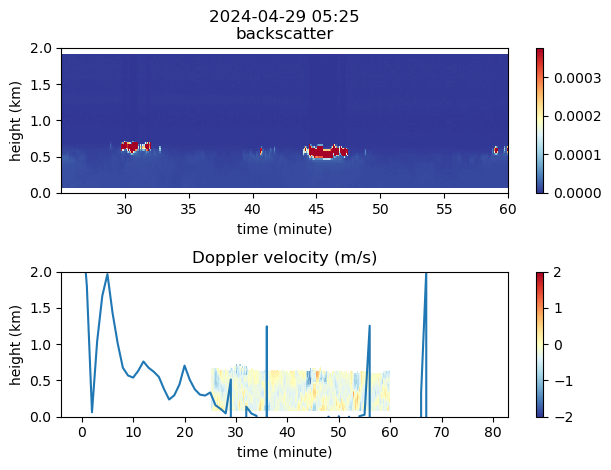

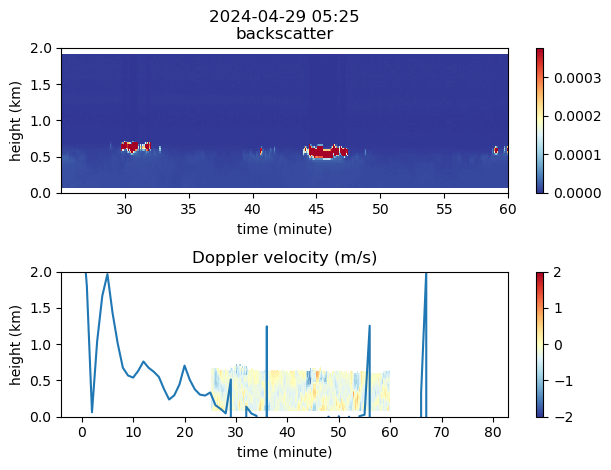

In [19]:
# plot 1 chunk
# show(epsi_tmp[ic,:])

fig = gcf()
clf()
pcolor_lidar_stare(fig, beams, LidarDt, Int(bigind_file_start), Int(bigind_file_end))
# python type error: TypeError: Image data of dtype object cannot be converted to float
plot(1e4 * epsi_tmp[ic,:])
gcf()

In [20]:
# rerun TEST diagnostic on a chunk that previously failed in production

nx = 4000
nz = 80
beams = init_periodic_beams(nx, nz)

epsi_tmp_fail = zeros(Float64, length(iens), nz) .- 5

ist_fail = 1_261_562
en_fail = 1_262_098
ic_fail = findfirst(ists .== ist_fail)
ic_fail = findfirst(ists .>= ist_fail)
isnothing(ic_fail) && error("Could not find failing chunk start ist=$(ist_fail)")
ien_fail = iens[ic_fail]
ien_fail == en_fail || @warn "Failing chunk end differs from saved log" ien_fail en_fail

ifile_fail = findlast(bigind_file_starts .<= ist_fail)
isnothing(ifile_fail) && error("No file start found for ic=$(ic_fail), ist=$(ist_fail)")
if ien_fail > bigind_file_ends[ifile_fail]
    error("Chunk ic=$(ic_fail) spans files; one-file diagnostic expects a single containing file")
end

bigind_file_start_fail = bigind_file_starts[ifile_fail]
bigind_file_end_fail = bigind_file_ends[ifile_fail]
print("\nfile $(ifile_fail) $(bigind_file_start_fail)---$(bigind_file_end_fail) chunk ")

h_fail = read_lidar.read_streamlinexr_head(ff[ifile_fail])
bb_fail = bigind_file_start_fail:bigind_file_end_fail
read_streamlinexr_stare!(ff[ifile_fail], h_fail, beams, bb_fail)

dt_chunk_fail = LidarDt["dtime"][ist_fail]
dopplervel_fail, pitch_fail, roll_fail, vn0_fail, vn1_fail, vn2_fail, Ur_fail, Vr_fail, mdv_fail =
    read_stare_chunk(dt_chunk_fail, beams, Vn, UV, ist_fail, ien_fail, nz)

println("\nfailing chunk diagnostics")
@printf("ic=%d ist=%d ien=%d nt=%d\n", ic_fail, ist_fail, ien_fail, ien_fail - ist_fail + 1)
diag_array("dopplervel", dopplervel_fail)
diag_array("pitch", pitch_fail)
diag_array("roll", roll_fail)
diag_array("vn0", vn0_fail)
diag_array("vn1", vn1_fail)
diag_array("vn2", vn2_fail)
diag_array("Ur", Ur_fail)
diag_array("Vr", Vr_fail)
diag_array("mdv", mdv_fail)

if any(isgoodnum.(Ur_fail)) && any(isgoodnum.(Vr_fail))
    # load vn2_aligned; fall back to mdv if VN not available for this chunk
    vn2_aligned_fail, _, _ = load_vn2_aligned(ic_fail, ist_fail, ien_fail, LidarDt["dtime"])
    if any(isfinite, vn2_aligned_fail)
        heave_fail = vn2_aligned_fail
    else
        valid_dv_fail = isgoodnum.(dopplervel_fail)
        jj_fail = vec(all(valid_dv_fail, dims=1))
        heave_fail = any(jj_fail) ? mean(dopplervel_fail[:, jj_fail], dims=2)[:] :
                                    fill(NaN, size(dopplervel_fail, 1))
    end

    len_fail = minimum((
        size(dopplervel_fail, 1),
        length(pitch_fail),
        length(roll_fail),
        size(Ur_fail, 1),
        size(Vr_fail, 1),
        length(heave_fail),
    ))
    @printf("len_fail=%d\n", len_fail)

    if len_fail >= 3
        w_fail = dopplervel_fail[1:len_fail, :] .- heave_fail[1:len_fail]
        D2bin_fail, rhobin_fail, A_fail, noise_fail = D2_rho_stare(
            w_fail,
            pitch_fail[1:len_fail] * pi / 180,
            roll_fail[1:len_fail] * pi / 180,
            Ur_fail[1:len_fail, :],
            Vr_fail[1:len_fail, :],
        )

        for iz in eachindex(A_fail)
            a = A_fail[iz]
            if ismissing(a)
                epsi_tmp_fail[ic_fail, iz] = -3
            elseif a >= 0
                epsi_tmp_fail[ic_fail, iz] = epsilon(a)
            else
                epsi_tmp_fail[ic_fail, iz] = -1
            end
        end
    else
        epsi_tmp_fail[ic_fail, :] .= -3
    end
else
    epsi_tmp_fail[ic_fail, :] .= -4
end

epsi_tmp_fail[ic_fail, :]


┌ Warning: Failing chunk end differs from saved log
│   ien_fail = 1262164
│   en_fail = 1262098
└ @ Main In[20]:15



file 395 1261086---1264322 chunk 
failing chunk diagnostics
ic=2361 ist=1261562 ien=1262164 nt=603
dopplervel size=(603, 80)      n= 48240 empty=false missing= 24081 finite= 24159 nan=     0
pitch      size=(603,)         n=   603 empty=false missing=     0 finite=     0 nan=   603
roll       size=(603,)         n=   603 empty=false missing=     0 finite=     0 nan=   603
vn0        size=(603,)         n=   603 empty=false missing=     0 finite=     0 nan=   603
vn1        size=(603,)         n=   603 empty=false missing=     0 finite=     0 nan=   603
vn2        size=(603,)         n=   603 empty=false missing=     0 finite=     0 nan=   603
Ur         size=(603, 80)      n= 48240 empty=false missing=     0 finite=     0 nan= 48240
Vr         size=(603, 80)      n= 48240 empty=false missing=     0 finite=     0 nan= 48240
mdv        size=(603,)         n=   603 empty=false missing=     0 finite=   603 nan=     0


80-element Vector{Float64}:
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
  ⋮
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0
 -4.0

In [ ]:
dtime_st[144]

2024-04-28T23:46:09.379

In [ ]:
# short run 4-29 12 to 4-30 00; ic=ist:285
# where VN is unsynced but seems to improve
# consistency of epsilon results.

# computes 20 chunks in 34 s

# VN correction only <==> MDV_FALLBACK=false; MDV_STRICT=false
MDV_FALLBACK = false
MDV_STRICT = false #| true

CALC_SIGMA_ANGLES = false
PLOT_STRUCTURE_FN = false

clf()

if false | true
# periodic buffer for data
nx = 4000
nz = 80
nbinmax = 17
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array for chunks; -9 is missing value
D2_tmp      = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
rho_tmp     = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
epsi_tmp = zeros(Float64, length(iens), nz) .- 9 
# fit quality metrics (saved alongside epsilon)
A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
nbins_tmp   = zeros(Int, length(iens), nz)
nrho_tmp    = zeros(Int, length(iens), nz)
R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
sigma_pitch_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
sigma_roll_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)

ifile_loaded = 0

# loop all chunk time indices, record missing for no Vn data
# for ic in eachindex(dtime_st)[213:285]
for ic in eachindex(dtime_st)[144:211]
    
    ist = ists[ic]
    ien = iens[ic]

    # map this chunk to its start file
    ifile_needed = findlast(bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$ist")

    # initialize so first load can jump directly toward needed file
    if ifile_loaded == 0
        ifile_loaded = ifile_needed - 1
        bigind_file_end = 0
    end

    # load one or more files until this chunk [ist, ien] is fully available in beams
    while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
        ifile_loaded += 1
        if ifile_loaded > length(ff)
            error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
        end

        bigind_file_start = bigind_file_starts[ifile_loaded]
        bigind_file_end   = bigind_file_ends[ifile_loaded]

        h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
        bb = bigind_file_start:bigind_file_end
        read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

        println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
    end
    print("$(ist)-$(ien) ")

    dt_chunk = LidarDt["dtime"][ist]
    dopplervel, pitch, roll, _, _, _, Ur, Vr, _ = read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien)

    # use vn2_aligned (synced heave) when available; fall back to mdv
    vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
    
    if CALC_SIGMA_ANGLES
        # fails when angles are missing
        σ_pitch = π / 180 * std( pitch_aligned[isfinite.(pitch_aligned)] ) # radians
        σ_roll  = π / 180 * std( roll_aligned[ isfinite.( roll_aligned)] )
    else
        σ_pitch = π / 180 * 20.0 # nominal 2 degree -> radians
        σ_roll  = π / 180 * 20.0
    end
    if !MDV_STRICT && any(isfinite, vn2_aligned)
        heave = vn2_aligned
        pitch = pitch_aligned # use VN synced angles
        roll = roll_aligned
    elseif MDV_STRICT || MDV_FALLBACK # fallback to mdv-based heave estimate
        valid_dv = isgoodnum.(dopplervel)
        jj = vec(all(valid_dv, dims=1))
        heave = any(jj) ? mean(dopplervel[:, jj], dims=2)[:] : fill(NaN, size(dopplervel, 1))
        pitch[:] .= 0 .* pitch  # zero pitch and roll if not using synced VN
        roll[:]  .= 0 .* roll
    else
        epsi_tmp[ic, :] .= -5 # code for missing heave data (both vn2_aligned and mdv fallback)
        continue # skip this chunk if vn2_aligned is not available, rather than using mdv fallback
    end

    if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
        len = minimum((
            size(dopplervel, 1),
            length(pitch),
            length(roll),
            size(Ur, 1),
            size(Vr, 1),
            length(heave),
        ))
        if len < 3
            epsi_tmp[ic, :] .= -3
            nbins_tmp[ic, :] .= 0
            continue
        end

        w = dopplervel[1:len, :] .- heave[1:len]
        D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho = 
            D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, 
                            Ur[1:len, :], Vr[1:len, :],
                            σ_pitch, σ_roll )
        if PLOT_STRUCTURE_FN
            plot(rhobin, D2bin)
            xlabel("rho")
            ylabel("D2")
        end

        # metrics are informational only; no gating of epsilon results
        nb = size(D2bin, 1)
        D2_tmp[ ic, :, 1:nb] .= D2bin'
        rho_tmp[ic, :, 1:nb] .= rhobin'

        A_tmp[ic, :] .= A_fit
        se_A_tmp[ic, :] .= se_A_fit
        nbins_tmp[ic, :] .= nbins_fit
        R2_tmp[ic, :] .= R2_fit
        RMSE_tmp[ic, :] .= RMSE_fit
        A_lo_tmp[ic, :] .= A_ci_lo
        nrho_tmp[ic, :] .= nrho
        A_hi_tmp[ic, :] .= A_ci_hi
        epsi_lo_tmp[ic, :] .= epsi_ci_lo
        epsi_hi_tmp[ic, :] .= epsi_ci_hi
        sigma_pitch_tmp[ic, :] .= σ_pitch
        sigma_roll_tmp[ic, :] .= σ_roll

        for iz in eachindex(A_fit)
            a = A_fit[iz]
            if ismissing(a)
                epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
            elseif a >= 0
                epsi_tmp[ic, iz] = epsilon(a)
            else
                epsi_tmp[ic, iz] = -1   # code for slope A <= 0
            end
        end
    else
        epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
        nbins_tmp[ic, :] .= 0
    end
end

# save: epsilon plus fit metrics
epsi = epsi_tmp
height = beams[:height]
A = A_tmp
se_A = se_A_tmp
nbins = nbins_tmp
nrho = nrho_tmp
sigma_pitch = sigma_pitch_tmp
sigma_roll = sigma_roll_tmp
savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
# @save joinpath("epsilon_data","epsi_stare_vn_chunks_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp nrho sigma_pitch sigma_roll
end
gcf()

# TLS shows slight improvement in troublesome cases


ic=144 ifile_loaded=24 bigind_file=73667-76869
76107-76643 NaN

ic=145 ifile_loaded=25 bigind_file=76870-80071
76644-77163 NaN
77164-77700 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [140]:
# clf()
# for ic in 213:220
#     for iz in 1:nz
#         ii = .!ismissing.(D2_tmp[ic, iz, :]) .& .!ismissing.(rho_tmp[ic, iz, :])
#         if any(ii)
#             plot(rho_tmp[ic, iz, ii], D2_tmp[ic, iz, ii])
#         end
#     end
# end
# gcf()

In [33]:
# plot scaled and compensated D2 structure function
C2 = 2.0  
d2_scaled(D2, rho, epsilon, nu=1.5e-5) = D2/(epsilon^(2/3) * rho)
# plot d2_scaled vs. r/η or rho*η^(-2/3)
# the linear property of rho doesn't matter, but we already combined
# horizontal and vertical displacements into rho

kolmogorov_length_scale(epsilon; nu=1.5e-5) = (nu^3 / epsilon)^0.25 # η
kolmogorov_vel_scale(epsilon; nu=1.5e-5) = sqrt(epsilon * nu)

"epsilon, noise, n = get_epsilon_noise(rho, D2)"
function get_epsilon_noise(rho::AbstractVector, D2::AbstractVector)
    # inputs binned by rho (rho = r^(2/3), ascending order)
    # D2 = A*rho + noise  =>  (D2-noise)/rho = A = C2 * epsilon^(2/3)
    # Use upper quartile to avoid the near-noise small-rho bins (which give D2_comp ≈ 0)
    C2 = 2.0

    ii = .!ismissing.(D2) .& .!ismissing.(rho)
    n = sum(ii)
    if n < 3
        return NaN, NaN, n
    else
        noise = minimum(D2[ii][1:5])
        D2_comp = (D2[ii] .- noise) ./ rho[ii]
        pos = D2_comp[6:end] .> 0
        if sum(pos) < 3
            return NaN, noise, n
        end
        epsilon = (median(D2_comp[6:end][pos]) / C2)^1.5
        return epsilon, noise, n
    end
end

sz = size(rho_tmp)[1:2]
epsi = -ones(sz)
noise = -ones(sz)
nfit = zeros(Int, sz)
for i in CartesianIndices(sz)
    epsi[i], noise[i], nfit[i] = @views get_epsilon_noise(rho_tmp[i, :], D2_tmp[i, :])
end

# for i in CartesianIndices(sz)
#     y = (D2_tmp[i,:] .- noise[i]) ./ rho_tmp[i,:]
#     ii = .!ismissing.(y) .& .!ismissing.(rho_tmp[i,:]) .& (y .> 0)
#     if any(ii)
#         plot(rho_tmp[i,ii], y[ii], linewidth=0.5)
#     end
# end
# yscale("log")


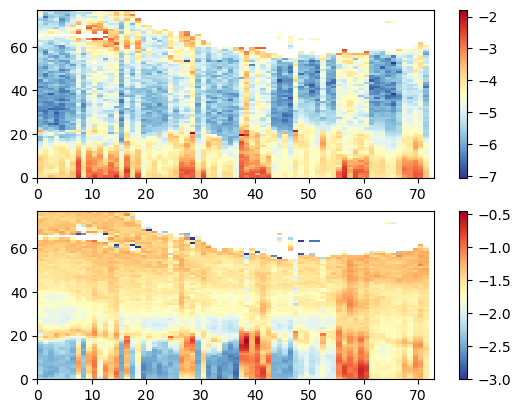

4632

In [24]:

Z = minimum(D2_tmp[213:285,4:end,:], dims=3)[:,:,1]
clf()
subplot(2,1,1)
pcolormesh(log10.(max.(0,epsi[213:285,4:end]))', cmap = ColorMap("RdYlBu_r"))
colorbar()# maximum(epsi[isfinite.(epsi)])
subplot(2,1,2)
pcolormesh(log10.(max.(0,noise[213:285,4:end]))', cmap = ColorMap("RdYlBu_r"), vmin=-3)
colorbar()# maximum(epsi[isfinite.(epsi)])
# size(rho_tmp), size(D2_tmp), sz, size(epsi), size(noise), size(nfit)
sum(epsi[213:285,4:end] .>= 0)
# plot( epsi[213:285,4:end] )
# any(isfinite.(epsi[213:285,4:end] .> 0))

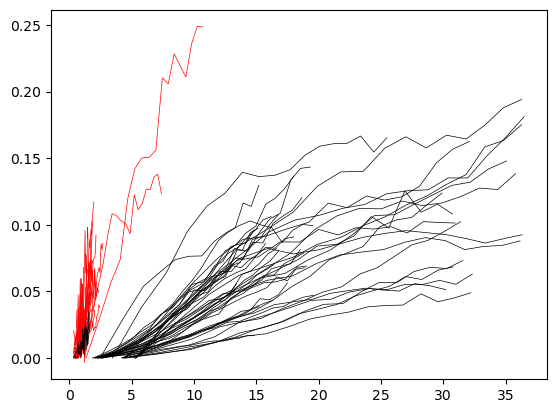

Python: [<matplotlib.lines.Line2D object at 0x401917e00>, <matplotlib.lines.Line2D object at 0x401bc81a0>, <matplotlib.lines.Line2D object at 0x401bc82f0>, <matplotlib.lines.Line2D object at 0x401bc8440>, <matplotlib.lines.Line2D object at 0x401bc8590>, <matplotlib.lines.Line2D object at 0x401bc86e0>, <matplotlib.lines.Line2D object at 0x401bc8830>, <matplotlib.lines.Line2D object at 0x401bc8980>, <matplotlib.lines.Line2D object at 0x401bc8ad0>, <matplotlib.lines.Line2D object at 0x401bc8c20>, <matplotlib.lines.Line2D object at 0x401bc8d70>, <matplotlib.lines.Line2D object at 0x401bc8ec0>, <matplotlib.lines.Line2D object at 0x401bc9010>, <matplotlib.lines.Line2D object at 0x401bc9160>, <matplotlib.lines.Line2D object at 0x401bc92b0>, <matplotlib.lines.Line2D object at 0x401bc9400>, <matplotlib.lines.Line2D object at 0x401bc9550>, <matplotlib.lines.Line2D object at 0x401bc96a0>, <matplotlib.lines.Line2D object at 0x401bc97f0>, <matplotlib.lines.Line2D object at 0x401bc9940>, <matplotlib

In [25]:
# plot level 7 and see spectra for high and low epsilon
ii = (epsi[213:285,7] .> 5e-4)
clf()
plot(rho_tmp[(213:285)[ii],7,:]', D2_tmp[(213:285)[ii],7,:]' .- noise[(213:285)[ii],7]', color="r", linewidth=0.5)
plot(rho_tmp[(213:285)[.!ii],7,:]', D2_tmp[(213:285)[.!ii],7,:]' .- noise[(213:285)[.!ii],7]', color="k", linewidth=0.5)
# xlim(0, 10)

High-epsilon chunks (epsi > 0.0005 at iz=7):
ic  | date-time           | wind(m/s) | sigma_pitch(deg) | noise    | max_rho | A_fit    | R2
220   2024-04-29T13:06:26.938  n/a         0.23°             0.0452    1.86     0.0694   0.887
222   2024-04-29T13:26:27.960  n/a         0.23°             0.0414    1.78     0.0458   0.922
224   2024-04-29T13:46:29.079  n/a         0.22°             0.0170    2.33     0.0279   0.958
225   2024-04-29T13:56:29.629  n/a         0.26°             0.0745    1.19     0.0197   0.356
226   2024-04-29T14:06:30.609  n/a         0.29°             0.0445    1.85     0.0441   0.851
227   2024-04-29T14:16:31.101  n/a         0.26°             0.1144    1.21     0.0212   0.349
229   2024-04-29T14:36:32.109  n/a         0.28°             0.0666    1.95     0.0803   0.929
231   2024-04-29T14:56:33.261  n/a         0.25°             0.0115    2.43     0.0194   0.917
239   2024-04-29T16:16:37.373  n/a         0.30°             0.0471    1.80     0.0585   0.930
240   

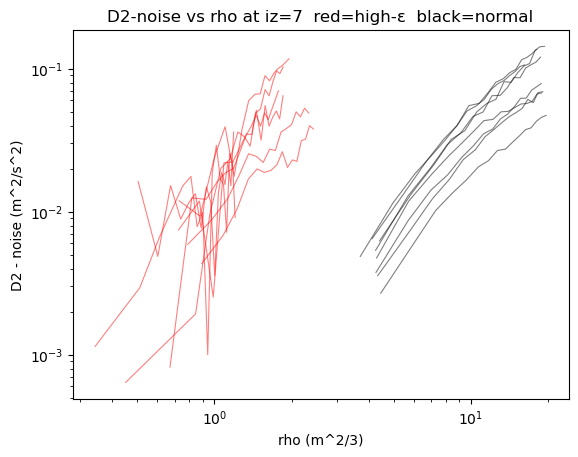

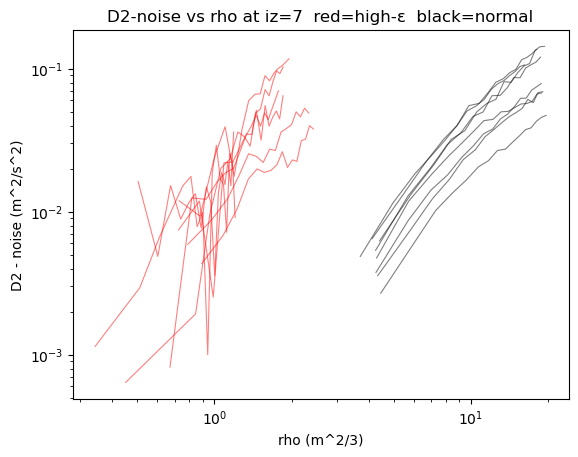

In [26]:
# DIAGNOSTIC: why is epsilon high on 4-29?
# For high-epsilon chunks, print key metadata and plot D2 vs rho.

ic_range = 213:285
iz_diag  = 7                    # level to examine
epsi_hi  = 5e-4                 # threshold: "anomalously high"

ic_bad = [ic for ic in ic_range if epsi[ic, iz_diag] > epsi_hi]
ic_ok  = [ic for ic in ic_range if 0 < epsi[ic, iz_diag] < epsi_hi]

println("High-epsilon chunks (epsi > $epsi_hi at iz=$iz_diag):")
println("ic  | date-time           | wind(m/s) | sigma_pitch(deg) | noise    | max_rho | A_fit    | R2")
for ic in ic_bad[1:min(10,end)]
    ist = ists[ic]
    dt  = dtime_st[ic]
    # wind at that level (Ur, Vr are in the UV dataset; use stored sigma_pitch as proxy)
    sp   = coalesce(sigma_pitch_tmp[ic, iz_diag], NaN) * 180/pi
    nval = coalesce(noise[ic, iz_diag], NaN)
    rmax = maximum(skipmissing(rho_tmp[ic, iz_diag, :]))
    aval = coalesce(A_tmp[ic, iz_diag], NaN)
    r2   = coalesce(R2_tmp[ic, iz_diag], NaN)
    @printf("%-4d  %s  n/a       %6.2f°           %8.4f  %6.2f   %8.4f  %6.3f\n",
            ic, dt, sp, nval, rmax, aval, r2)
end

# Plot D2-noise vs rho for high vs normal chunks at this level
clf()
for ic in ic_bad[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn, 
             color="r", alpha=0.5, linewidth=0.8)
    end
end
for ic in ic_ok[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn,
             color="k", alpha=0.5, linewidth=0.8)
    end
end
xlabel("rho (m^2/3)"); ylabel("D2 - noise (m^2/s^2)")
title("D2-noise vs rho at iz=$iz_diag  red=high-ε  black=normal")
yscale("log"); xscale("log")

# Also print raw noise levels to see if noise is truly large or just rho range is small
println("\nNoise comparison (iz=$iz_diag):")
@printf("bad  median noise = %.4e  median max_rho = %.2f\n",
    median(filter(isfinite, [coalesce(noise[ic,iz_diag],NaN) for ic in ic_bad])),
    median(filter(isfinite, [maximum(skipmissing(rho_tmp[ic,iz_diag,:])) for ic in ic_bad])))
@printf("good median noise = %.4e  median max_rho = %.2f\n",
    median(filter(isfinite, [coalesce(noise[ic,iz_diag],NaN) for ic in ic_ok])),
    median(filter(isfinite, [maximum(skipmissing(rho_tmp[ic,iz_diag,:])) for ic in ic_ok])))
gcf()


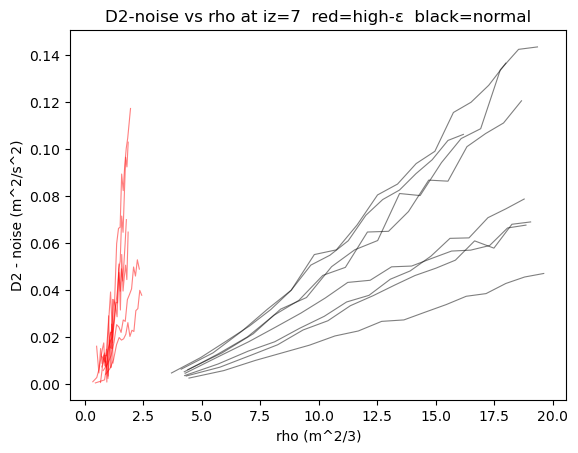

Python: Text(0.5, 1.0, 'D2-noise vs rho at iz=7  red=high-ε  black=normal')

In [27]:
clf()
for ic in ic_bad[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn, 
             color="r", alpha=0.5, linewidth=0.8)
    end
end
for ic in ic_ok[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn,
             color="k", alpha=0.5, linewidth=0.8)
    end
end
xlabel("rho (m^2/3)"); ylabel("D2 - noise (m^2/s^2)")
title("D2-noise vs rho at iz=$iz_diag  red=high-ε  black=normal")

In [28]:

# DIAGNOSTIC: why is rho 10x smaller for high-epsilon chunks?
# Two candidate causes:
#   A. Short chunk (small nt) → max Δit is small → max wind advection is small
#   B. Wind speed near zero or NaN from UV at those chunk times

iz_diag = 7
epsi_hi = 5e-4
ic_range = 213:285

ic_bad = [ic for ic in ic_range if epsi[ic, iz_diag] > epsi_hi]
ic_ok  = [ic for ic in ic_range if 0 < epsi[ic, iz_diag] < epsi_hi]

# helper: look up mean wind speed from UV for a chunk time window
function chunk_windspeed(ist, ien, iz; uv=UV, dtime=LidarDt["dtime"])
    t_start = dtime[ist]
    t_end   = dtime[ien]
    uvt = uv["time"][:]
    jj = findall(t_start .<= uvt .<= t_end)
    isempty(jj) && return NaN, NaN
    ur_col = uv[:ur][:, jj]
    vr_col = uv[:vr][:, jj]
    # iz indexes the lidar range gate; UV may have different z dimension
    nz_uv = size(ur_col, 1)
    iz_uv = min(iz, nz_uv)
    ur_vals = filter(isfinite, Float64.(ur_col[iz_uv, :]))
    vr_vals = filter(isfinite, Float64.(vr_col[iz_uv, :]))
    ur_mean = isempty(ur_vals) ? NaN : mean(ur_vals)
    vr_mean = isempty(vr_vals) ? NaN : mean(vr_vals)
    return ur_mean, vr_mean
end

println("ic   nt    U(m/s)  V(m/s) |UV|(m/s)  max_rho_obs  max_rho_pred(wind)  sigma_p(°)  epsi")
println("---  ----  ------  ------  --------  -----------  ------------------  ----------  ----")
for ic in sort([ic_bad; ic_ok[1:min(5,end)]])
    ist  = ists[ic]
    ien  = iens[ic]
    nt   = ien - ist + 1
    ur, vr = chunk_windspeed(ist, ien, iz_diag)
    wspd = isfinite(ur) && isfinite(vr) ? sqrt(ur^2 + vr^2) : NaN
    # expected rho from wind advection at max lag (nt-1 seconds), capped at Lscale_max
    rho_pred = isfinite(wspd) ? min(wspd * (nt - 1) * timestep, 3500.0)^(2/3) : NaN
    rho_obs  = maximum(skipmissing(rho_tmp[ic, iz_diag, :]))
    sp       = coalesce(sigma_pitch_tmp[ic, iz_diag], NaN) * 180/pi
    ei       = epsi[ic, iz_diag]
    tag = ei > epsi_hi ? " ← bad" : ""
    @printf("%-4d %-5d  %6.2f  %6.2f  %7.2f   %9.3f    %9.3f           %5.2f°  %.2e%s\n",
            ic, nt, isfinite(ur) ? ur : NaN, isfinite(vr) ? vr : NaN, wspd,
            rho_obs, rho_pred, sp, ei, tag)
end


ic   nt    U(m/s)  V(m/s) |UV|(m/s)  max_rho_obs  max_rho_pred(wind)  sigma_p(°)  epsi
---  ----  ------  ------  --------  -----------  ------------------  ----------  ----
213  519      2.93   -0.92     3.07      17.997      138.017            0.23°  1.86e-04
214  537      2.76   -1.26     3.03      18.781      140.096            0.21°  7.56e-05
215  537      2.64   -0.28     2.65      19.055      128.151            0.21°  6.65e-05
216  537      3.23   -0.64     3.29      19.616      148.016            0.25°  3.53e-05
217  537      3.15   -1.05     3.32      19.349      148.890            0.25°  1.69e-04
220  537      1.93   -0.12     1.94       1.856      103.890            0.23°  2.52e-03 ← bad
222  537      3.57   -1.48     3.86       1.778      164.618            0.23°  1.64e-03 ← bad
224  537      3.37   -1.08     3.54       2.331      155.177            0.22°  9.92e-04 ← bad
225  519      3.39   -0.37     3.41       1.190      147.941            0.26°  6.05e-04 ← bad
226  537  

In [ ]:
# DIAGNOSTIC: check Udt[izo] indexing bug for bad vs good chunks
# Hypothesis: Udt = Ur*timestep is (nt,nz) 2D; Udt[izo] = Udt[izo,1] (linear index)
# => uses wind at TIME STEP izo, HEIGHT 1, not wind at height izo

# pick one confirmed-bad and one confirmed-good chunk from the diagnostic table
# check their Ur[:,1] values at indices 1:nz
ic_test_bad  = ic_bad[1]   # e.g. first bad chunk
ic_test_good = ic_ok[1]    # e.g. first good chunk

function get_Ur_for_chunk(ic_pick)
    ist_p = ists[ic_pick]; ien_p = iens[ic_pick]
    # find and load the file
    ifile_p = findlast(bigind_file_starts .<= ist_p)
    bfs = bigind_file_starts[ifile_p]; bfe = bigind_file_ends[ifile_p]
    beams_p = init_periodic_beams(4000, 80)
    h_p = read_lidar.read_streamlinexr_head(ff[ifile_p])
    read_streamlinexr_stare!(ff[ifile_p], h_p, beams_p, bfs:bfe)
    dt_chunk_p = LidarDt["dtime"][ist_p]
    _, _, _, _, _, _, Ur_p, Vr_p, _ = read_stare_chunk(dt_chunk_p, beams_p, Vn, UV, ist_p, ien_p)
    return Ur_p
end

println("=== BAD chunk ic=$ic_test_bad ===")
Ur_bad = get_Ur_for_chunk(ic_test_bad)
nt_bad = size(Ur_bad, 1); nz_bad = size(Ur_bad, 2)
@printf("Ur size: nt=%d nz=%d\n", nt_bad, nz_bad)
@printf("mean(Ur[:,1]) (height-1 wind) = %.2f m/s\n", mean(filter(isfinite, Ur_bad[:,1])))
@printf("mean(Ur[:,40])                = %.2f m/s\n", mean(filter(isfinite, Ur_bad[:,40])))
println("Udt[izo,1] for izo=1:nz (used as effective wind per height level):")
Udt_bad = Ur_bad .* timestep
@printf("  izo=1:  %.4f  izo=40: %.4f  izo=80: %.4f  (should be the same if UV is constant)\n",
    Udt_bad[1,1], Udt_bad[40,1], Udt_bad[min(80,nt_bad),1])
println("First 10 values of Ur[:,1]: ", Ur_bad[1:min(10,nt_bad), 1])

println()
println("=== GOOD chunk ic=$ic_test_good ===")
# commented out bc it errors:
# Ur_good = get_Ur_for_chunk(ic_test_good)
# nt_good = size(Ur_good, 1); nz_good = size(Ur_good, 2)
# @printf("Ur size: nt=%d nz=%d\n", nt_good, nz_good)
# @printf("mean(Ur[:,1]) (height-1 wind) = %.2f m/s\n", mean(filter(isfinite, Ur_good[:,1])))
# @printf("mean(Ur[:,40])                = %.2f m/s\n", mean(filter(isfinite, Ur_good[:,40])))
# Udt_good = Ur_good .* timestep
# @printf("  izo=1:  %.4f  izo=40: %.4f  izo=80: %.4f\n",
#     Udt_good[1,1], Udt_good[40,1], Udt_good[min(80,nt_good),1])
# println("First 10 values of Ur[:,1]: ", Ur_good[1:min(10,nt_good), 1])


=== BAD chunk ic=220 ===
Ur size: nt=537 nz=80
mean(Ur[:,1]) (height-1 wind) = 0.86 m/s
mean(Ur[:,40])                = 2.70 m/s
Udt[izo,1] for izo=1:nz (used as effective wind per height level):
  izo=1:  -0.0900  izo=40: -0.0900  izo=80: -0.0900  (should be the same if UV is constant)
First 10 values of Ur[:,1]: Union{Missing, Float64}[-0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837, -0.08821912109851837]

=== GOOD chunk ic=213 ===


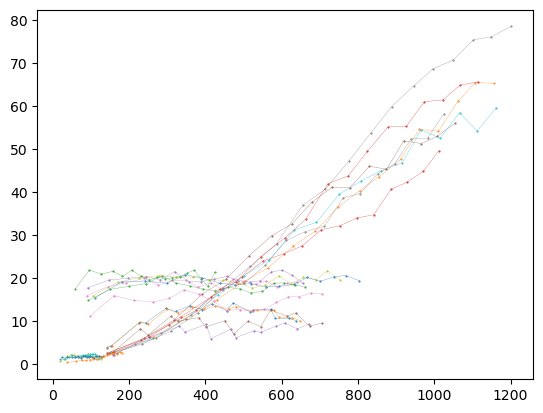

In [32]:
# plot compensated structure function vs. compensated scale to check for collapse
clf()
for ic in 213:220
    for iz in 1:4
        if !ismissing(epsi_tmp[ic, iz]) && (epsi_tmp[ic, iz] > 0)
            ii = .!ismissing.(D2_tmp[ic, iz, :]) .& .!ismissing.(rho_tmp[ic, iz, :])
            if any(ii)
                η = kolmogorov_length_scale(max(0, epsi_tmp[ic, iz]))
                # plot(rho_tmp[ic, iz, ii] * η^(-2/3), 
                #     d2_scaled.(D2_tmp[ic, iz, ii], rho_tmp[ic, iz, ii], epsi_tmp[ic,iz]))
                plot(rho_tmp[ic, iz, ii] * η^(-2/3), 
                    D2_tmp[ic, iz, ii] ./ minimum(D2_tmp[ic, iz, ii]./rho_tmp[ic, iz, ii]),
                    linewidth=0.2, marker='.', markersize=1)
                # plot(rho_tmp[ic, iz, ii] * η^(-2/3), 
                #     D2_tmp[ic, iz, ii]./rho_tmp[ic, iz, ii].^1.04 ./ minimum(D2_tmp[ic, iz, ii]./rho_tmp[ic, iz, ii]),
                #     linewidth=0.2, marker='.', markersize=1)

            end
        end
    end
end
# ylim([0, 7])
# xscale("log")
# noise looks like noise / (epsilon^2/3 * rho)
# D2 = D2_true + noise
# D2_true = C2 * epsilon^(2/3) * rho
# D2_scaled = D2 / (epsilon^(2/3) * rho)
# epsilon = (minimum(D2-noise) / (C2 * rho))^1.5

Dissipation from displacements less than rho ~ 5 are probably not good.

In [125]:
# TEST 1: Load DisplacementUncertainty module and estimate pitch/roll uncertainties

# DisplacementUncertainty functions available via DopplerTurbulence

# GATE: Choose uncertainty estimation method
USE_ESTIMATED_SIGMA = false  # Set to false to use conservative fixed values

if USE_ESTIMATED_SIGMA
    # Branch A: Estimate from VN data (problematic period 4-29 12:00 to 4-30 00:00)
    test_ic_range = 213:285
    
    test_pitch = Float64[]
    test_roll = Float64[]
    
    for ic in test_ic_range
        ist, ien = ists[ic], iens[ic]
        vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
        
        if any(isfinite, vn2_aligned)
            append!(test_pitch, filter(isfinite, pitch_aligned))
            append!(test_roll, filter(isfinite, roll_aligned))
        end
    end
    
    σ_pitch, σ_roll = estimate_pitch_roll_uncertainty(test_pitch, test_roll)
    
    println("Estimated from VN data:")
    println("  σ_pitch = $(rad2deg(σ_pitch))° ($(σ_pitch) rad)")
    println("  σ_roll  = $(rad2deg(σ_roll))° ($(σ_roll) rad)")
    println("  n_samples: $(length(test_pitch))")
else
    # Branch B: Use conservative fixed values (ACTIVE)
    σ_pitch = deg2rad(2.0)
    σ_roll = deg2rad(2.0)
    
    println("Using conservative fixed uncertainties:")
    println("  σ_pitch = 2.0° ($(σ_pitch) rad)")
    println("  σ_roll  = 2.0° ($(σ_roll) rad)")
    println("  Rationale: VN angle quality not yet assessed for this period")
end

Using conservative fixed uncertainties:
  σ_pitch = 2.0° (0.03490658503988659 rad)
  σ_roll  = 2.0° (0.03490658503988659 rad)
  Rationale: VN angle quality not yet assessed for this period


In [126]:
# TEST 2: Test displacement_variance_pitch_roll - scaling with range

println("\n" * "="^70)
println("TEST 2: Displacement uncertainty vs range")
println("="^70)

rangegate = 24.0
test_ranges = [(10, 12), (10, 20), (10, 30), (10, 50), (20, 60)]  # (iz1, iz2) pairs

pitch1, pitch2 = deg2rad(0.5), deg2rad(0.8)
roll1, roll2 = deg2rad(-0.3), deg2rad(0.4)

println("\nUsing: σ_pitch=$(rad2deg(σ_pitch))°, σ_roll=$(rad2deg(σ_roll))°\n")
println("Range separation    | σ_dr (m) | σ_dz (m) | Relative")
println("-"^70)

for (iz1, iz2) in test_ranges
    rng1 = rangegate * (iz1 - 1 + 0.5)
    rng2 = rangegate * (iz2 - 1 + 0.5)
    Δr = rng2 - rng1
    δdr2_loop, δdz2_loop = DopplerTurbulence.displacement_variance_pitch_roll(
        rng1, rng2, pitch1, pitch2, roll1, roll2, σ_pitch, σ_roll)
    σ_dr = sqrt(δdr2_loop)
    σ_dz = sqrt(δdz2_loop)
    rel_unc = σ_dr / Δr * 100
    @printf("%4.0fm - %4.0fm (Δr=%3.0fm) | %6.2f   | %6.2f   | %5.1f%%\n",
            rng1, rng2, Δr, σ_dr, σ_dz, rel_unc)
end

# Compute sample values outside loop for TEST 3 (loop scope is local)
rng1_sample, rng2_sample = 240.0, 720.0
δdr2, δdz2 = DopplerTurbulence.displacement_variance_pitch_roll(
    rng1_sample, rng2_sample, pitch1, pitch2, roll1, roll2, σ_pitch, σ_roll)
println("\nSample for TEST 3: δdr2=$(δdr2) m², δdz2=$(δdz2) m²")



TEST 2: Displacement uncertainty vs range

Using: σ_pitch=2.0°, σ_roll=2.0°

Range separation    | σ_dr (m) | σ_dz (m) | Relative
----------------------------------------------------------------------
 228m -  276m (Δr= 48m) |  17.67   |   0.17   |  36.8%
 228m -  468m (Δr=240m) |  25.70   |   0.27   |  10.7%
 228m -  708m (Δr=480m) |  36.72   |   0.39   |   7.6%
 228m - 1188m (Δr=960m) |  59.71   |   0.65   |   6.2%
 468m - 1428m (Δr=960m) |  74.18   |   0.80   |   7.7%

Sample for TEST 3: δdr2=1403.5485893766997 m², δdz2=0.16117840011229517 m²


In [127]:
# TEST 3: Test propagate_rho_uncertainty

test_dr2 = [100.0, 400.0, 1000.0, 4000.0]  # m²
test_dz2 = [25.0,  100.0,  250.0, 1000.0]  # m²

println("\nRho uncertainty propagation test:")
println("Using δdr2=$(δdr2) m², δdz2=$(δdz2) m²\n")

for (dr2, dz2) in zip(test_dr2, test_dz2)
    var_rho = DopplerTurbulence.propagate_rho_uncertainty(dr2, dz2, δdr2, δdz2)
    rho = dr2^(1/3) * (1 - dz2/(4*dr2))
    if !ismissing(var_rho)
        σ_rho = sqrt(var_rho)
        println("dr=$(sqrt(dr2))m dz=$(sqrt(dz2))m: ρ=$(round(rho,digits=3)) σ_ρ=$(round(σ_rho,digits=4)) ($(round(σ_rho/rho*100,digits=1))%)")
    end
end



Rho uncertainty propagation test:
Using δdr2=1403.5485893766997 m², δdz2=0.16117840011229517 m²

dr=10.0m dz=5.0m: ρ=4.351 σ_ρ=0.6521 (15.0%)
dr=20.0m dz=10.0m: ρ=6.908 σ_ρ=0.2588 (3.7%)
dr=31.622776601683793m dz=15.811388300841896m: ρ=9.375 σ_ρ=0.1405 (1.5%)
dr=63.245553203367585m dz=31.622776601683793m: ρ=14.882 σ_ρ=0.0558 (0.4%)


In [70]:
# load PSL met data
# candidate files in order of preference
files = [ "/mnt/c/Users/deszoeks/Data/EKAMSAT/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "~/Data/ASTRAL/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/SSTcompare/data/PSL/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/mast/data/SSTcompare/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc" ]
filename = files[findfirst(isfile, files)]
psl = NCDataset(filename)
psltime = psl["time"][:] # @. DateTime(2024,1,1,0,0) + Second(round(Int, psl["time"][:]))
keys(psl) |> filter(k -> contains(string(k), "cl"))


2-element Vector{String}:
 "sw_down_clear"
 "lw_down_clear"

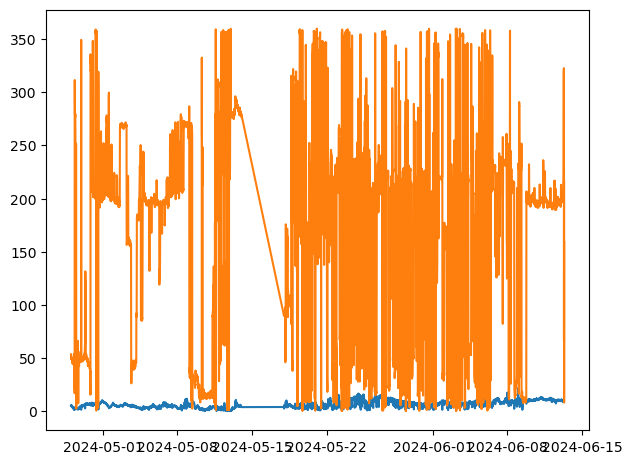

In [ ]:
ii = map(t -> !ismissing(t) && isfinite(t), psltime) # all good
clf()
subplot(2,1,1)
plot(psltime, psl["wspd"][:], label="wspd")
plot(psltime, psl["heading"][:], label="heading")
gcf()

In [136]:
# get stare data for 4-29 1300
starepath = "/Users/deszoeks/Projects/lidar/ASTRAL2024/data/netcdf_stare"
starefiles = readdir(starepath) |> filter(f -> 
    "Stare_116_20240429_12.nc" <= f <= "Stare_116_20240430_00.nc")

clf()
subplot(2,1,1)
for sf in starefiles
    stare = NCDataset(joinpath(starepath, sf))
    # starekeys = keys(stare)
    pcolormesh(stare["time"][1:10:end], stare["height"][4:end]/1e3, stare["intensity"][1:10:end,4:end]', vmin = 0.5, vmax = 2)
end
ylim([0, 0.7])
gcf()
keys(stare)

12-element Vector{String}:
 "time"
 "gate"
 "height"
 "azimuth"
 "elevangle"
 "pitch"
 "roll"
 "dopplervel"
 "intensity"
 "beta"
 "mdv_snr_mean"
 "n_mdv_realizations"

In [112]:
dtime_st[213]

2024-04-29T11:56:22.381

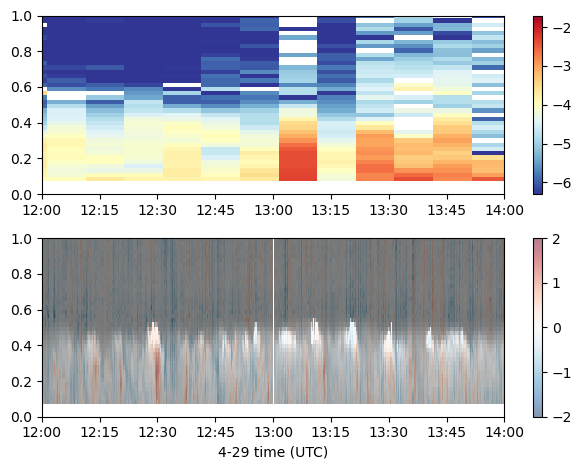

In [138]:
# plot problematic time 4-29 12 to 4-30 00
let ist = 213, ien = 285

clf()
ax1 = subplot(2,1,1)
pcolormesh(dtime_st[ist:ien], height[4:end]/1e3, log10.(max.(0,epsi_tmp[ist:ien,4:end]')), 
    cmap=ColorMap("RdYlBu_r"), shading="nearest", vmin=log10(5e-7), vmax=log10(2e-2))
# plot(UV[:time], sqrt.(UV[:ur][20,:].^2 .+ UV[:vr][20,:].^2)./10, "k-", linewidth=0.5) # 480 m
colorbar()
ylim([0, 1])
xlim([dtime_st[ist], dtime_en[ien]])
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))

subplot(2,1,2, sharex=ax1)
# plot(dtime_st[ist:ien], 180/π .* sigma_roll_tmp[ist:ien])
# plot(dtime_st[ist:ien], 180/π .* sigma_pitch[ist:ien])
# plot(psltime, psl["heading"][:], "k-", linewidth=0.5 )
# plot(psltime, psl["heading"][:], label="heading")
# plot(psltime, psl["rspd"][:], label="heading")
# plot(psltime, psl["rdir"][:], label="rdir") # all fine
# plot(psltime, psl["sw_down"][:], label="sw_dn") # OK
for sf in starefiles
    stare = NCDataset(joinpath(starepath, sf))
    # starekeys = keys(stare)
    pcolormesh(stare["time"][1:10:end], stare["height"][4:end]/1e3, stare["intensity"][1:10:end,4:end]', 
        vmin = 1.05, vmax = 1.8, cmap=ColorMap("gray"), shading="nearest")
    pcolormesh(stare["time"][1:10:end], stare["height"][4:end]/1e3, 
        stare["dopplervel"][1:10:end,4:end]', # .- stare["mdv_snr_mean"][1:10:end]', 
        vmin=-2, vmax = 2, cmap=ColorMap("RdBu_r"), 
        alpha=0.5, shading="nearest")
end
colorbar()
# plot(psltime, psl["lw_down"][:], label="lw_dn") # OK
# plot(psltime, psl["prate"][:]) # all zero
ylim([0, 1])
# xlim([dtime_st[213], dtime_en[285]])
xlim([dtime_st[ist], dtime_en[ien]])
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))
xlabel("4-29 time (UTC)")
tight_layout()
gcf()
end
# not obviously correlated to wind speed
# propagating large errors throughout does not affect the very dissipations for

xlim([DateTime(2024, 4, 29, 12, 0, 0), DateTime(2024,4,29,14)])
gcf()

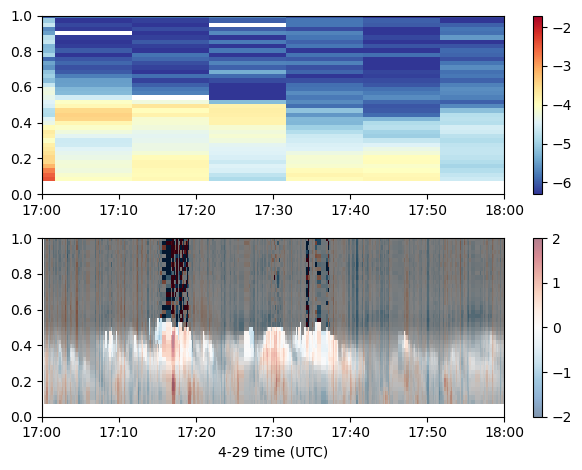

In [129]:
xlim([DateTime(2024, 4, 29, 17), DateTime(2024,4,29,18)])
gcf()

In [ ]:
# loop through ALL chunks, load next file as data is needed
# takes 105 min on laptop

# VN correction only <==> MDV_FALLBACK=false; MDV_STRICT=false
MDV_FALLBACK = false
MDV_STRICT = false

if false | true # do not rerun!
# periodic buffer for data
nx = 4000
nz = 80
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array for chunks; -9 is missing value
epsi_tmp = zeros(Float64, length(iens), nz) .- 9 
# fit quality metrics (saved alongside epsilon)
A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
nbins_tmp   = zeros(Int, length(iens), nz)
nrho_tmp    = zeros(Int, length(iens), nz)
R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)

ifile_loaded = 0

# loop all chunk time indices, record missing for no Vn data
for ic in eachindex(dtime_st)
    ist = ists[ic]
    ien = iens[ic]

    # map this chunk to its start file
    ifile_needed = findlast(bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$ist")

    # initialize so first load can jump directly toward needed file
    if ifile_loaded == 0
        ifile_loaded = ifile_needed - 1
        bigind_file_end = 0
    end

    # load one or more files until this chunk [ist, ien] is fully available in beams
    while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
        ifile_loaded += 1
        if ifile_loaded > length(ff)
            error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
        end

        bigind_file_start = bigind_file_starts[ifile_loaded]
        bigind_file_end   = bigind_file_ends[ifile_loaded]

        h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
        bb = bigind_file_start:bigind_file_end
        read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

        println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
    end
    print("$(ist)-$(ien) ")

    dt_chunk = LidarDt["dtime"][ist]
    dopplervel, pitch, roll, _, _, _, Ur, Vr, _ = read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien)

    # use vn2_aligned (synced heave) when available; fall back to mdv
    vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
    if !MDV_STRICT && any(isfinite, vn2_aligned)
        heave = vn2_aligned
        pitch = pitch_aligned # use VN synced angles
        roll = roll_aligned
    elseif MDV_STRICT || MDV_FALLBACK # fallback to mdv-based heave estimate
        valid_dv = isgoodnum.(dopplervel)
        jj = vec(all(valid_dv, dims=1))
        heave = any(jj) ? mean(dopplervel[:, jj], dims=2)[:] : fill(NaN, size(dopplervel, 1))
        pitch[:] .= 0  # zero pitch and roll if not using synced VN
        roll[:]  .= 0
    else
        epsi_tmp[ic, :] .= -5 # code for missing heave data (both vn2_aligned and mdv fallback)
        continue # skip this chunk if vn2_aligned is not available, rather than using mdv fallback
    end

    if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
        len = minimum((
            size(dopplervel, 1),
            length(pitch),
            length(roll),
            size(Ur, 1),
            size(Vr, 1),
            length(heave),
        ))
        if len < 3
            epsi_tmp[ic, :] .= -3
            nbins_tmp[ic, :] .= 0
            continue
        end

        w = dopplervel[1:len, :] .- heave[1:len]
        D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho = 
            D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, Ur[1:len, :], Vr[1:len, :])

        # metrics are informational only; no gating of epsilon results
        A_tmp[ic, :] .= A_fit
        se_A_tmp[ic, :] .= se_A_fit
        nbins_tmp[ic, :] .= nbins_fit
        R2_tmp[ic, :] .= R2_fit
        RMSE_tmp[ic, :] .= RMSE_fit
        A_lo_tmp[ic, :] .= A_ci_lo
        nrho_tmp[ic, :] .= nrho
        A_hi_tmp[ic, :] .= A_ci_hi
        epsi_lo_tmp[ic, :] .= epsi_ci_lo
        epsi_hi_tmp[ic, :] .= epsi_ci_hi

        for iz in eachindex(A_fit)
            a = A_fit[iz]
            if ismissing(a)
                epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
            elseif a >= 0
                epsi_tmp[ic, iz] = epsilon(a)
            else
                epsi_tmp[ic, iz] = -1   # code for slope A <= 0
            end
        end
    else
        epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
        nbins_tmp[ic, :] .= 0
    end
end

# save: epsilon plus fit metrics
epsi = epsi_tmp
height = beams[:height]
A = A_tmp
se_A = se_A_tmp
nbins = nbins_tmp
nrho = nrho_tmp
savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
@save joinpath("epsilon_data","epsi_stare_vn_chunks_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp nrho
end



ic=1 ifile_loaded=1 bigind_file=1-3202
1-243 244-780 781-1317 1318-1854 1855-2391 2392-2928 
ic=7 ifile_loaded=2 bigind_file=3203-6405
2929-3448 3449-3985 3986-4522 4523-5059 5060-5596 5597-6133 
ic=13 ifile_loaded=3 bigind_file=6406-9608
6134-6653 6654-7190 7191-7727 7728-8264 8265-8801 8802-9338 
ic=19 ifile_loaded=4 bigind_file=9609-12811
9339-9858 9859-10395 10396-10932 10933-11469 11470-12006 12007-12543 
ic=25 ifile_loaded=5 bigind_file=12812-16014
12544-13063 13064-13600 13601-14137 14138-14674 14675-15211 15212-15748 
ic=31 ifile_loaded=6 bigind_file=16015-19217
15749-16268 16269-16805 16806-17342 17343-17879 17880-18416 18417-18953 
ic=37 ifile_loaded=7 bigind_file=19218-22419
18954-19473 19474-20010 20011-20547 20548-21084 21085-21621 21622-22158 
ic=43 ifile_loaded=8 bigind_file=22420-25622
22159-22678 22679-23215 23216-23752 23753-24289 24290-24826 24827-25363 
ic=49 ifile_loaded=9 bigind_file=25623-28825
25364-25883 25884-26420 26421-26957 26958-27494 27495-28031 28032-28

In [ ]:
# postproduction compute epsilon uncertainties

# timestamps = [ "20260505_1508",
#                "20260506_1233" ]
# timestamps = [ "20260505_1508",
#                "20260506_1233" ]
timestamps = [ "20260508_0919",
               "20260508_1212" ]
# epsi_stare_vn_chunks_r20260508_1212.jld
# epsi_stare_vn_chunks_r20260508_0919.jld

for timestamp in timestamps
    # latest_file = last(sort(
    #     filter(f -> startswith(f, filtstring) && endswith(f, ".jld"), readdir("epsilon_data"))))
    latest_file = "epsi_stare_vn_chunks_r$(timestamp).jld"
    outfile = joinpath("epsilon_data", latest_file)
    res = load_se_epsilon_jld(outfile) # not a Dict, but a NamedTuple with keys: se_epsilon, rel_se_epsilon, A, se_A, epsi

    s_se = finite_summary(res.se_epsilon)
    s_rel = finite_summary(res.rel_se_epsilon)

    jldsave(joinpath("epsilon_data", "epsi_se_r$(timestamp).jld"), s_se=s_se)

    @info "loaded" outfile
    @printf("se_epsilon:      n=%d p50=%s p90=%s p99=%s\n", s_se.n, string(s_se.p50), string(s_se.p90), string(s_se.p99))
    @printf("se_epsilon/epsi: n=%d p50=%s p90=%s p99=%s\n", s_rel.n, string(s_rel.p50), string(s_rel.p90), string(s_rel.p99))
end

In [ ]:
timestamps = [ "20260505_1508",
               "20260506_1233",
               "20260507_0712",
               "20260507_0005",
               "20260508_0919",
               "20260508_1212" ]

timestamp = timestamps[5]
latest_file = "epsi_stare_vn_chunks_r$(timestamp).jld"
outfile = joinpath("epsilon_data", latest_file)
data = load(outfile) # dict

dtime_st = data["dtime_st"] # truncated
dtime_en = data["dtime_en"]
height   = data["height"]
epsi     = data["epsi"]
nbins    = data["nbins"]

last(data["dtime_st"])

In [ ]:
idx = map(c-> c[1], findall( any(epsi .> 0, dims=2) ) ) # any chunk has data that is not missing
# mask = nbins .> 12
mask = nrho .> 100_000 # good

xlims = [ DateTime("2024-04-29T00:00:00"), DateTime("2024-06-11T00:00:00") ]

cmap = PythonPlot.matplotlib.cm.get_cmap("RdBu_r", 15)
norm = PythonPlot.matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-1)

clf()
subplot(2,1,1)
pcolormesh( dtime_en, height./1e3, pd(max.(0,mask.*epsi)),
    cmap=cmap, norm=norm)
colorbar()
xlim(xlims)
ax = gca()
ax.set_facecolor("gray")
ax.xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
PythonPlot.matplotlib.pyplot.setp(ax.get_xticklabels(), rotation=60) #, ha="right")

subplot(2,1,2)
pcolormesh( dtime_en, height./1e3, pd(nrho), cmap=cmap, vmin=0 )
colorbar()
xlim(xlims)
ax = gca()
ax.xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
PythonPlot.matplotlib.pyplot.setp(ax.get_xticklabels(), rotation=60) #, ha="right")

tight_layout()
gcf()


In [ ]:
#= diagnostics for the file just written above
outfile  = joinpath("epsilon_data", "epsi_stare_chunks_r$(savetime).jld")
@info "diagnostics file" outfile

dat = load(outfile)
epsi_diag = dat["epsi"]
dtime_diag = dat["dtime_st"]
height_diag = dat["height"]

# cell-wise fractions
total_cells = length(epsi_diag)
neg_cells = count(x -> !ismissing(x) && isfinite(x) && x < 0, epsi_diag)
pos_cells = count(x -> !ismissing(x) && isfinite(x) && x > 0, epsi_diag)
miss_cells = count(ismissing, epsi_diag)

@printf("total_cells = %d\n", total_cells)
@printf("negative_cells = %d (%.6f)\n", neg_cells, neg_cells / total_cells)
@printf("positive_cells = %d (%.6f)\n", pos_cells, pos_cells / total_cells)
@printf("missing_cells = %d (%.6f)\n", miss_cells, miss_cells / total_cells)

for code in (-5.0, -4.0, -3.0)
    ncode = count(x -> !ismissing(x) && isfinite(x) && x == code, epsi_diag)
    @printf("code %d cells = %d (%.6f)\n", Int(code), ncode, ncode / total_cells)
end

# row-wise "any positive epsilon" fraction
rows_with_any_positive = count(any((!ismissing).(row) .& isfinite.(row) .& (row .> 0)) for row in eachrow(epsi_diag))
nrows = size(epsi_diag, 1)
@printf("rows_with_any_positive = %d / %d (%.6f)\n", rows_with_any_positive, nrows, rows_with_any_positive / nrows)

# positive values in requested log range
valid_pos = Float64[x for x in epsi_diag if !ismissing(x) && isfinite(x) && x > 0]
inrange = count(x -> (3e-6 <= x <= 3e-3), valid_pos)
@printf("positive in [3e-6, 3e-3] = %d / %d (%.6f)\n", inrange, length(valid_pos), inrange / max(1, length(valid_pos)))

# log-scale time-height plot
eps_plot = Float64.(coalesce.(epsi_diag, NaN))
eps_plot[(.!isfinite.(eps_plot)) .| (eps_plot .<= 0)] .= NaN

clf()
norm = PyPlot.matplotlib.colors.LogNorm(vmin=3e-6, vmax=3e-3)
pcolormesh(dtime_diag, height_diag, pd(eps_plot[:, 1:length(height_diag)]), cmap=ColorMap("RdYlBu_r"), norm=norm)
cb = colorbar()
cb.set_label("epsilon (m^2 s^-3)")
ylabel("height (m)")
xlabel("time")
title("epsi diagnostics: $(basename(outfile))")
gcf()
=#